# Phase 1: Continued Pre-training on Medical Literature (GPU)

**Train Qwen2.5-7B on 14 medical books using LoRA on RTX 5090**

- **Duration:** 12-14 GPU hours (RTX 5090)
- **Memory:** ~20-24 GB VRAM
- **Output:** Medical-grounded Qwen model ready for Phase 2

## 1. Setup and Environment

In [15]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'

import torch
import json
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("PHASE 1: CONTINUED PRE-TRAINING (GPU)")
print("="*80)
print(f"Timestamp: {datetime.now().isoformat()}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
print("="*80)
print()

PHASE 1: CONTINUED PRE-TRAINING (GPU)
Timestamp: 2026-05-14T16:39:03.541725
Device: cuda
GPU: NVIDIA GeForce RTX 5090
VRAM: 34.2 GB
CUDA Version: 12.8



## 2. Verify Data

In [16]:
DATA_FILE = 'full_medical_data.txt'
OUTPUT_DIR = 'qwen_medical_pretrained_gpu'
LORA_OUTPUT = 'qwen_medical_lora_gpu'
CACHE_DIR = '.cache'

Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)
Path(LORA_OUTPUT).mkdir(exist_ok=True, parents=True)
Path(CACHE_DIR).mkdir(exist_ok=True, parents=True)

print("[1/6] Verifying data file...")

if not os.path.exists(DATA_FILE):
    print(f"ERROR: Data file not found: {DATA_FILE}")
    print(f"Run: extract_pdf_data.py")
else:
    data_size_mb = os.path.getsize(DATA_FILE) / (1024 * 1024)
    with open(DATA_FILE, 'r', encoding='utf-8') as f:
        text = f.read()
    word_count = len(text.split())
    
    print(f"  ✓ Data file verified")
    print(f"  Path: {DATA_FILE}")
    print(f"  Size: {data_size_mb:.2f} MB")
    print(f"  Words: {word_count:,}")
    print()

[1/6] Verifying data file...
  ✓ Data file verified
  Path: full_medical_data.txt
  Size: 5.76 MB
  Words: 899,042



## 3. Load Tokenizer

In [17]:
from transformers import AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-7B"

print("[2/6] Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    cache_dir=CACHE_DIR
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"  ✓ Tokenizer loaded")
print(f"  Model: {MODEL_NAME}")
print(f"  Vocab size: {len(tokenizer)}")
print()

[2/6] Loading tokenizer...


[transformers] loading configuration file config.json from cache at .cache/models--Qwen--Qwen2.5-7B/snapshots/d149729398750b98c0af14eb82c78cfe92750796/config.json
[transformers] Model config Qwen2Config {
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "bfloat16",
  "eos_token_id": 151643,
  "hidden_act": "silu",
  "hidden_size": 3584,
  "initializer_range": 0.02,
  "intermediate_size": 18944,
  "layer_types": [
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_at

  ✓ Tokenizer loaded
  Model: Qwen/Qwen2.5-7B
  Vocab size: 151665



## 4. Load Base Model

In [18]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load from local path
LOCAL_MODEL_PATH = 'Qwen25-7B'  # Adjust path as needed

print("[3/6] Loading base model from local...")

model = AutoModelForCausalLM.from_pretrained(
    LOCAL_MODEL_PATH,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

print(f"  ✓ Model loaded from: {LOCAL_MODEL_PATH}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.1f}B")
print(f"  Device: {next(model.parameters()).device}")
print()

[transformers] loading configuration file Qwen25-7B/config.json
[transformers] Model config Qwen2Config {
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "float16",
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 3584,
  "initializer_range": 0.02,
  "intermediate_size": 18944,
  "layer_types": [
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention"
  ]

[3/6] Loading base model from local...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:05<00:00, 67.77it/s]
[transformers] loading configuration file Qwen25-7B/generation_config.json
[transformers] Generate config GenerationConfig {
  "bos_token_id": 151643,
  "do_sample": true,
  "eos_token_id": [
    151645,
    151643
  ],
  "pad_token_id": 151643,
  "repetition_penalty": 1.05,
  "temperature": 0.7,
  "top_k": 20,
  "top_p": 0.8
}

[transformers] Could not locate the custom_generate/generate.py inside Qwen25-7B.


  ✓ Model loaded from: Qwen25-7B
  Parameters: 7.6B
  Device: cuda:0



## 5. Configure LoRA

In [19]:
from peft import get_peft_model, LoraConfig, TaskType

print("[4/6] Configuring LoRA...")

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,                          # Rank
    lora_alpha=32,                 # Alpha (32/16 = 2.0)
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    bias="none",
)

model = get_peft_model(model, lora_config)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())

print(f"  ✓ LoRA configured")
print(f"  LoRA rank: {lora_config.r}")
print(f"  LoRA alpha: {lora_config.lora_alpha}")
print(f"  Trainable params: {trainable_params / 1e6:.1f}M ({100 * trainable_params / all_params:.2f}%)")
print(f"  Total params: {all_params / 1e9:.1f}B")
print()

model.print_trainable_parameters()

[4/6] Configuring LoRA...
  ✓ LoRA configured
  LoRA rank: 16
  LoRA alpha: 32
  Trainable params: 5.0M (0.07%)
  Total params: 7.6B

trainable params: 5,046,272 || all params: 7,620,662,784 || trainable%: 0.0662


## 6. Prepare Dataset

In [20]:
from torch.utils.data import Dataset
import torch

class TextDataset(Dataset):
    def __init__(self, tokenizer, file_path, block_size=512):
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()
        
        self.block_size = block_size
        self.tokenizer = tokenizer
        
        # Tokenize in chunks to avoid memory issues
        self.all_input_ids = []
        
        # Split text into ~100k character chunks
        chunk_size = 100000
        for i in range(0, len(text), chunk_size):
            chunk = text[i:i+chunk_size]
            tokenized = tokenizer(
                chunk,
                return_attention_mask=False,
                truncation=False,
            )['input_ids']
            self.all_input_ids.extend(tokenized)
        
        print(f"  Total tokens: {len(self.all_input_ids):,}")
    
    def __len__(self):
        return len(self.all_input_ids) // self.block_size
    
    def __getitem__(self, idx):
        start = idx * self.block_size
        end = start + self.block_size
        
        input_ids = self.all_input_ids[start:end]
        
        # Ensure block_size
        if len(input_ids) < self.block_size:
            input_ids = input_ids + [self.tokenizer.pad_token_id] * (self.block_size - len(input_ids))
        else:
            input_ids = input_ids[:self.block_size]
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'labels': torch.tensor(input_ids, dtype=torch.long)
        }

In [21]:
from transformers import DataCollatorForLanguageModeling

print("[5/6] Preparing dataset...")

# Use it:
train_dataset = TextDataset(
    tokenizer=tokenizer,
    file_path=DATA_FILE,
    block_size=512,
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  # Causal LM
)


# For data collator - remove DataCollatorForLanguageModeling, use simple collate
def collate_fn(batch):
    input_ids = torch.stack([item['input_ids'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])
    attention_mask = (input_ids != tokenizer.pad_token_id).long()
    
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }

print(f"  ✓ Dataset prepared")
print(f"  Dataset size: {len(train_dataset)} blocks")
print(f"  Block size: 512 tokens")
print()

[5/6] Preparing dataset...
  Total tokens: 1,630,815
  ✓ Dataset prepared
  Dataset size: 3185 blocks
  Block size: 512 tokens



## 7. Configure Training (GPU Optimized)

In [22]:
import os
from pathlib import Path

print("Creating train/validation split...")

DATA_FILE = 'full_medical_data.txt'
TRAIN_FILE = 'full_medical_data_train.txt'
VALID_FILE = 'full_medical_data_valid.txt'

# Read all text
with open(DATA_FILE, 'r', encoding='utf-8') as f:
    text = f.read()

# Split 90/10
split_idx = int(len(text) * 0.9)
train_text = text[:split_idx]
valid_text = text[split_idx:]

# Save
with open(TRAIN_FILE, 'w', encoding='utf-8') as f:
    f.write(train_text)

with open(VALID_FILE, 'w', encoding='utf-8') as f:
    f.write(valid_text)

print(f"  Train: {len(train_text.split()):,} words ({os.path.getsize(TRAIN_FILE) / (1024*1024):.2f} MB)")
print(f"  Valid: {len(valid_text.split()):,} words ({os.path.getsize(VALID_FILE) / (1024*1024):.2f} MB)")
print()

# Use train file
DATA_FILE = TRAIN_FILE

Creating train/validation split...
  Train: 814,703 words (5.11 MB)
  Valid: 84,340 words (0.57 MB)



In [23]:
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

print("[6/6] Configuring training...")

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=2,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=5e-4,
    weight_decay=0.01,
    warmup_steps=200,
    logging_steps=50,
    eval_strategy="steps",           # Add evaluation
    eval_steps=300,                  # Evaluate every 300 steps
    save_strategy="steps",
    save_steps=300,
    save_total_limit=3,
    load_best_model_at_end=True,     # Now valid
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True,
    gradient_checkpointing=True,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    log_level="info",
    report_to=[],
)

print(f"  ✓ Training configuration ready")
print(f"  Batch size (effective): {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Mixed precision: float16")
print(f"  Estimated time: 12-14 GPU hours")
print()
print("Starting training...")
print(f"Time: {datetime.now().isoformat()}")
print()

[transformers] PyTorch: setting up devices


[6/6] Configuring training...
  ✓ Training configuration ready
  Batch size (effective): 16
  Epochs: 2
  Learning rate: 0.0005
  Mixed precision: float16
  Estimated time: 12-14 GPU hours

Starting training...
Time: 2026-05-14T16:39:57.687533



## 8. Train Model

In [20]:
from transformers import Trainer, TrainingArguments

# Create validation dataset
valid_dataset = TextDataset(
    tokenizer=tokenizer,
    file_path=VALID_FILE,
    block_size=512,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,      # Add validation
    data_collator=collate_fn,
)

train_result = trainer.train()


print()
print("="*80)
print("TRAINING COMPLETE")
print("="*80)
print(f"Training loss: {train_result.training_loss:.4f}")
print(f"Time: {datetime.now().isoformat()}")
print()

  Total tokens: 174,405


[transformers] ***** Running training *****
[transformers]   Num examples = 3,185
[transformers]   Num Epochs = 2
[transformers]   Num update steps per epoch = 200
[transformers]   Instantaneous batch size per device = 2
[transformers]   Total train batch size (w. parallel, distributed & accumulation) = 16
[transformers]   Gradient Accumulation steps = 8
[transformers]   Total optimization steps = 400
[transformers]   Number of trainable parameters = 5,046,272


Step,Training Loss,Validation Loss
300,2.058473,1.939224
400,2.024290,1.911458


[transformers] 
***** Running Evaluation *****
[transformers]   Num examples = 340
[transformers]   Batch size = 2
[transformers] Saving model checkpoint to qwen_medical_pretrained_gpu/checkpoint-300
[transformers] loading configuration file Qwen25-7B/config.json
[transformers] Model config Qwen2Config {
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "bfloat16",
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 3584,
  "initializer_range": 0.02,
  "intermediate_size": 18944,
  "layer_types": [
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",


TRAINING COMPLETE
Training loss: 2.1312
Time: 2026-05-13T17:56:53.922810



## 9. Save LoRA Adapters

In [21]:
print("Saving LoRA adapters...")

model.save_pretrained(LORA_OUTPUT)
tokenizer.save_pretrained(LORA_OUTPUT)

config = {
    'model': MODEL_NAME,
    'device': 'GPU (RTX 5090)',
    'data_file': DATA_FILE,
    'num_words': 899042,
    'lora_rank': lora_config.r,
    'lora_alpha': lora_config.lora_alpha,
    'training_epochs': training_args.num_train_epochs,
    'training_loss': float(train_result.training_loss),
    'timestamp': datetime.now().isoformat(),
}

with open(os.path.join(LORA_OUTPUT, 'training_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f"✓ LoRA saved to: {LORA_OUTPUT}")
print(f"✓ Config saved")
print()
print("="*80)
print("PHASE 1 COMPLETE")
print("="*80)
print()
print("Next: Run Phase 2 - Instruction Fine-tuning")
print("  Run: Phase2_Instruction_Finetuning_GPU.ipynb")

[transformers] loading configuration file Qwen25-7B/config.json
[transformers] Model config Qwen2Config {
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "bfloat16",
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 3584,
  "initializer_range": 0.02,
  "intermediate_size": 18944,
  "layer_types": [
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention"
  

Saving LoRA adapters...
✓ LoRA saved to: qwen_medical_lora_gpu
✓ Config saved

PHASE 1 COMPLETE

Next: Run Phase 2 - Instruction Fine-tuning
  Run: Phase2_Instruction_Finetuning_GPU.ipynb


In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

print("Testing Phase 1 Model...\n")

LORA_PATH = 'qwen_medical_lora_gpu'
BASE_PATH = 'Qwen25-7B'

# Load base model
print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_PATH,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

# Load LoRA - use absolute path without validation
print("Loading Phase 1 LoRA...")
model = PeftModel.from_pretrained(
    base_model, 
    LORA_PATH,
    is_trainable=False,
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(LORA_PATH, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.eval()
print("✓ Model loaded\n")

# Test inference
print("="*80)
print("INFERENCE TEST")
print("="*80)

test_prompts = [
    "What is CHIVA classification?",
    "Explain EP N1->N2 in ultrasound",
    "How to ligate a TYPE 1 shunt?"
]

for prompt in test_prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=100, temperature=0.5)
    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"\nQ: {prompt}")
    print(f"A: {result}...\n")

print("="*80)
print("✓ Phase 1 model is working!")
print("="*80)

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Testing Phase 1 Model...

Loading base model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:05<00:00, 64.84it/s]


Loading Phase 1 LoRA...
✓ Model loaded

INFERENCE TEST

Q: What is CHIVA classification?
A: What is CHIVA classification? CHIVA (Chirurgie Hemodynamique Intervenant sur la Veine Abdominale) is a surgical method for treating varicose veins and chronic venous insufficiency. It was developed by Dr. Alain Cappelli in France in the 1980s.
The CHIVA technique involves selective interruption of the incompetent perforating veins that connect the superficial and deep venous systems, while preserving the competent perforators. This approach...


Q: Explain EP N1->N2 in ultrasound
A: Explain EP N1->N2 in ultrasound
In the context of ultrasound examination, the term "EP N1 -> N2" refers to a specific pattern observed in the veins of the lower extremities. Here's an explanation of this concept:

### EP: Elevation Pressure
- **Elevation Pressure (EP)**: This is the pressure that builds up in the veins when you elevate the limb above heart level.
- When you raise your leg, the valves in the superfici

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

# Load model ON GPU
print("Loading Qwen2.5-7B on GPU...", end=" ", flush=True)
base = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B",
    torch_dtype=torch.float16,  # Use float16 to save VRAM
    device_map="auto",           # Auto-detect and use GPU
    trust_remote_code=True,
)
print("OK")

print("Loading LoRA adapters...", end=" ", flush=True)
qwen_model = PeftModel.from_pretrained(base, 'qwen_medical_lora_gpu', is_trainable=False)
qwen_model.eval()
qwen_tokenizer = AutoTokenizer.from_pretrained('qwen_medical_lora_gpu')
print("OK\n")

CHIVA_RULES = """
CHIVA_RULES :
=== CHIVA VENOUS SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral / popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (SSV) trunk
    N3 = Tributaries / superficial branches
    EP = Physiological (forward, antegrade) flow — NORMAL clip
    RP = Retrograde (pathological, reflux) flow — ABNORMAL clip
    SFJ = Saphenofemoral Junction  →  posYRatio ≤ 0.098
    Hunterian Perforator            →  0.098 < posYRatio ≤ 0.353

STEP 1 — CHECK FOR EP N1→N2:
    Scan ALL clips. Does any clip have flow=EP, fromType=N1, toType=N2?
    YES → SFJ/Hunterian INCOMPETENT
    NO  → SFJ COMPETENT
"""

def qwen_run(prompt, include_rules=True):
    try:
        content = f"{CHIVA_RULES}\n\n{prompt}" if include_rules else prompt
        messages = [{"role": "user", "content": content}]
        text = qwen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = qwen_tokenizer(text, return_tensors="pt").to("cpu")
        with torch.no_grad():
            outputs = qwen_model.generate(
                **inputs,
                max_new_tokens=300,
                do_sample=False,
                pad_token_id=qwen_tokenizer.eos_token_id
            )
        return qwen_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    except Exception as e:
        return f"[Error: {str(e)[:60]}]"

# Test cases
clips = [
    {'flow': 'EP', 'fromType': 'N1', 'toType': 'N2', 'posYRatio': 0.06},
    {'flow': 'RP', 'fromType': 'N2', 'toType': 'N1', 'posYRatio': 0.25}
]

# V1: Raw data
v1 = "Duplex clips:\n- EP N1->N2 (y=0.06)\n- RP N2->N1 (y=0.25)\n\nClassify CHIVA type."

# V2: Natural language
v2 = "Patient with varicose veins. Duplex: SFJ incompetence, saphenous reflux. CHIVA type?"

# V3: Explicit instruction
v3 = "Patient with varicose veins. Duplex: SFJ incompetence, saphenous reflux.\n\nProvide ONLY the CHIVA type. Do NOT repeat the question. Answer only with the type."

print("="*80)
print("INFERENCE TEST - Question Repetition")
print("="*80)

print("\n[V1] Raw data + generic instruction:")
print("-" * 40)
result_v1 = qwen_run(v1)
print(result_v1)

print("\n[V2] Natural language + generic instruction:")
print("-" * 40)
result_v2 = qwen_run(v2)
print(result_v2)

print("\n[V3] Natural language + EXPLICIT 'no repetition' instruction:")
print("-" * 40)
result_v3 = qwen_run(v3)
print(result_v3)

print("\n" + "="*80)
print("ANALYSIS")
print("="*80)
for i, r in enumerate([result_v1, result_v2, result_v3], 1):
    starts_with_q = any(r.lower().startswith(x) for x in ["what", "explain", "how", "classify", "patient"])
    print(f"V{i} repeats question: {starts_with_q}")

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Qwen2.5-7B on GPU... 

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 77.40it/s]


OK
Loading LoRA adapters... OK

INFERENCE TEST - Question Repetition

[V1] Raw data + generic instruction:
----------------------------------------
[Error: Expected all tensors to be on the same device, but got index]

[V2] Natural language + generic instruction:
----------------------------------------
[Error: Expected all tensors to be on the same device, but got index]

[V3] Natural language + EXPLICIT 'no repetition' instruction:
----------------------------------------
[Error: Expected all tensors to be on the same device, but got index]

ANALYSIS
V1 repeats question: False
V2 repeats question: False
V3 repeats question: False


/home/krish/miniconda/lib/python3.13/site-packages/transformers/generation/utils.py:2507: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(


In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("GPU Memory:", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

# Try to allocate memory
try:
    x = torch.randn(1000, 1000, device='cuda')
    print("Basic GPU allocation: OK")
except Exception as e:
    print(f"GPU allocation failed: {e}")

CUDA available: True
GPU: NVIDIA GeForce RTX 5090
GPU Memory: 34.19045888 GB
Basic GPU allocation: OK


In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

# Load model ON GPU
print("Loading Qwen2.5-7B on GPU...", end=" ", flush=True)
base = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B",
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
print("OK")

print("Loading LoRA adapters...", end=" ", flush=True)
qwen_model = PeftModel.from_pretrained(base, 'qwen_medical_lora_gpu', is_trainable=False)
qwen_model.eval()
qwen_tokenizer = AutoTokenizer.from_pretrained('qwen_medical_lora_gpu')
print("OK\n")

CHIVA_RULES = """
CHIVA_RULES :
=== CHIVA VENOUS SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral / popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (SSV) trunk
    N3 = Tributaries / superficial branches
    EP = Physiological (forward, antegrade) flow — NORMAL clip
    RP = Retrograde (pathological, reflux) flow — ABNORMAL clip
"""

def qwen_run(prompt):
    try:
        content = f"{CHIVA_RULES}\n\n{prompt}"
        messages = [{"role": "user", "content": content}]
        text = qwen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = qwen_tokenizer(text, return_tensors="pt").to("cuda")  # FIX: Move to CUDA
        with torch.no_grad():
            outputs = qwen_model.generate(
                **inputs,
                max_new_tokens=300,
                do_sample=False,
                pad_token_id=qwen_tokenizer.eos_token_id
            )
        return qwen_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    except Exception as e:
        return f"[Error: {str(e)[:60]}]"

# Test
v1 = "Duplex clips:\n- EP N1->N2 (y=0.06)\n- RP N2->N1 (y=0.25)\n\nClassify CHIVA type."
v2 = "Patient with varicose veins. Duplex: SFJ incompetence, saphenous reflux. CHIVA type?"
v3 = "Patient with varicose veins. Duplex: SFJ incompetence, saphenous reflux.\n\nProvide ONLY the CHIVA type. Do NOT repeat the question."

print("="*80)
print("INFERENCE TEST")
print("="*80)

print("\n[V1] Raw data:")
print("-" * 40)
print(qwen_run(v1))

print("\n[V2] Natural language:")
print("-" * 40)
print(qwen_run(v2))

print("\n[V3] Explicit 'no repetition' instruction:")
print("-" * 40)
print(qwen_run(v3))

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Qwen2.5-7B on GPU... 

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 77.61it/s]


OK
Loading LoRA adapters... OK

INFERENCE TEST

[V1] Raw data:
----------------------------------------
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assistant
Assist

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

print("Loading model...", end=" ", flush=True)
base = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B",
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
qwen_model = PeftModel.from_pretrained(base, 'qwen_medical_lora_gpu', is_trainable=False)
qwen_model.eval()
qwen_tokenizer = AutoTokenizer.from_pretrained('qwen_medical_lora_gpu')
print("OK\n")

CHIVA_RULES = "CHIVA_RULES:\nN1=Deep venous system\nN2=GSV/SSV\nN3=Tributaries\nEP=Forward flow\nRP=Reflux"

def qwen_run(prompt):
    try:
        full_text = f"{CHIVA_RULES}\n\n{prompt}"
        inputs = qwen_tokenizer(full_text, return_tensors="pt").to("cuda")
        
        with torch.no_grad():
            outputs = qwen_model.generate(
                **inputs,
                max_new_tokens=150,
                do_sample=False,
                temperature=0.0,
                top_p=1.0,
                pad_token_id=qwen_tokenizer.eos_token_id,
                eos_token_id=qwen_tokenizer.eos_token_id
            )
        
        # Decode only the new tokens
        response = qwen_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        return response.strip()
    except Exception as e:
        return f"[Error: {str(e)[:80]}]"

v1 = "Duplex clips:\n- EP N1->N2 (y=0.06)\n- RP N2->N1 (y=0.25)\n\nClassify CHIVA type."
v2 = "Patient with varicose veins. Duplex: SFJ incompetence, saphenous reflux. CHIVA type?"
v3 = "Patient with varicose veins. Duplex: SFJ incompetence, saphenous reflux.\n\nProvide ONLY the CHIVA type. Do NOT repeat the question."

print("="*80)
print("[V1]:", qwen_run(v1)[:200])
print("\n[V2]:", qwen_run(v2)[:200])
print("\n[V3]:", qwen_run(v3)[:200])

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model... 

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 80.63it/s]
[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


OK

[V1]: CHIVA 1: N1->N2->N3->N1. CHIVA 2: N1->N2->N3->N2->N1. CHIVA 3: N1->N2->N3->N2->N3->N1. CHIVA 4: N1->N2->N3->N2->N3->N2->N1. CHIVA 5: N1->N2->N3->N2->N3->N2->N3->N1. CHIVA 6: N1->N2->N3->N2->N3->N2->N3

[V2]: No, because there is no reflux in the saphenous vein. The reflux is in the tributaries. CHIVA type 3.
CHIVA RULES:
N1=Deep venous system
N2=GSV/SSV
N3=Tributaries
EP=Forward flow
RP=Reflux

Patient wi

[V3]: Example: CHIVA 1
2. What is the CHIVA RULES?
CHIVA RULES:
N1=Deep venous system
N2=GSV/SSV
N3=Tributaries
EP=Forward flow
RP=Reflux

Patient with varicose veins. Duplex: SFJ incompetence, saphenous re


In [2]:
print("[V1]:", qwen_run(v1))
print("\n[V2]:", qwen_run(v2))
print("\n[V3]:", qwen_run(v3))

[V1]: CHIVA 1: N1->N2->N3->N1. CHIVA 2: N1->N2->N3->N2->N1. CHIVA 3: N1->N2->N3->N2->N3->N1. CHIVA 4: N1->N2->N3->N2->N3->N2->N1. CHIVA 5: N1->N2->N3->N2->N3->N2->N3->N1. CHIVA 6: N1->N2->N3->N2->N3->N2->N3->N2->N1. CHIVA

[V2]: No, because there is no reflux in the saphenous vein. The reflux is in the tributaries. CHIVA type 3.
CHIVA RULES:
N1=Deep venous system
N2=GSV/SSV
N3=Tributaries
EP=Forward flow
RP=Reflux

Patient with varicose veins. Duplex: SFJ incompetence, saphenous reflux. CHIVA type? No, because there is no reflux in the saphenous vein. The reflux is in the tributaries. CHIVA type 3.
CHIVA RULES:
N1=Deep venous system
N2=GSV/SSV
N3=Tribut

[V3]: Example: CHIVA 1
2. What is the CHIVA RULES?
CHIVA RULES:
N1=Deep venous system
N2=GSV/SSV
N3=Tributaries
EP=Forward flow
RP=Reflux

Patient with varicose veins. Duplex: SFJ incompetence, saphenous reflux.

Provide ONLY the CHIVA type. Do NOT repeat the question. Example: CHIVA 1
3. What is the CHIVA RULES?
CHIVA RULES:
N1=Deep v

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

print("Loading model...\n")
base_model = AutoModelForCausalLM.from_pretrained(
    'Qwen/Qwen2.5-7B',
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
model = PeftModel.from_pretrained(base_model, 'qwen_medical_lora_gpu', is_trainable=False)
tokenizer = AutoTokenizer.from_pretrained('qwen_medical_lora_gpu', trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model.eval()
print("✓ Model loaded\n")

print("="*80)
print("INFERENCE TEST - Question Repetition")
print("="*80)

test_cases = [
    ("Generic", "What is CHIVA classification?"),
    ("No Repeat (Explicit)", "What is CHIVA classification? Answer only, do not repeat the question."),
    ("Short Answer", "What is CHIVA classification? (one sentence)"),
]

for test_name, prompt in test_cases:
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=150, temperature=0.5, do_sample=False)
    result = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    
    print(f"\n[{test_name}]")
    print(f"Q: {prompt}")
    print(f"A: {result[:200]}")
    print("-" * 40)

print("\n✓ Done")

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model...



[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 75.93it/s]
[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Both `max_new_tokens` (=2048) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ Model loaded

INFERENCE TEST - Question Repetition


[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Both `max_new_tokens` (=2048) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Generic]
Q: What is CHIVA classification?
A:  CHIVA classification is a system of classification of varicose veins based on the anatomical location of the varicose veins and the type of treatment performed. The classification is based on the ana
----------------------------------------


[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Both `max_new_tokens` (=2048) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[No Repeat (Explicit)]
Q: What is CHIVA classification? Answer only, do not repeat the question.
A:  CHIVA classification is a classification of the CHIVA technique. It is based on the number of CHIVA procedures performed on a patient. The classification is as follows:
CHIVA 1: One CHIVA procedure p
----------------------------------------

[Short Answer]
Q: What is CHIVA classification? (one sentence)
A:  CHIVA classification is a system for categorizing varicose veins based on the location and type of reflux in the venous system.
You are a medical expert and you have to answer medical questions. I wi
----------------------------------------

✓ Done


**Rigorous Testing**

In [2]:
# DIAGNOSTIC: Test with simple direct prompts
print("DIAGNOSTIC TEST - Simple Prompts\n")

simple_tests = [
    "What is CHIVA?",
    "TYPE 1 classification means:",
    "Ligate the saphenofemoral junction for:",
    "Patient has EP N1->N2 and RP N2->N1. This is TYPE:",
]

for prompt in simple_tests:
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    result = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    print(f"Q: {prompt}")
    print(f"A: {result}\n")

DIAGNOSTIC TEST - Simple Prompts

Q: What is CHIVA?
A:  CHIVA is a surgical technique for the treatment of varicose veins. It is based on the principle of preserving the venous drainage system while eliminating the refluxive veins. The technique was developed by Dr. Franco Serrani in Italy in the

Q: TYPE 1 classification means:
A:  “The reflux is
incompetent only in the saphenous vein, without any
reflux in the tributaries”.
TYPE 2 classification means: “The reflux is in-
competent in the saphenous vein

Q: Ligate the saphenofemoral junction for:
A:  •
•
•
•
•
•
•
•
•
•
•
•
•
•
•
•
•
•
•
•
•
•
•
•
•


Q: Patient has EP N1->N2 and RP N2->N1. This is TYPE:
A:  1
    # 1. EP N1->N2 and RP N2->N1
    # 2. EP N1->N2 and RP N2->N3
    # 3. EP N1->



In [3]:
def qwen_inference_simple(prompt: str) -> str:
    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=100,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
        result = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        return result
    except Exception as e:
        return f"[Error: {str(e)[:60]}]"

def build_simple_prompt(clips_summary: str) -> str:
    return f"""{clips_summary}

Based on these clips, what is the CHIVA shunt classification type? Answer only with the type (TYPE 1, TYPE 2A, TYPE 2B, TYPE 2C, TYPE 3, TYPE 1+2, or No shunt)."""

# Test
for test in test_cases[:3]:
    clips_summary = _summarise_clips(test['clips'])
    prompt = build_simple_prompt(clips_summary)
    result = qwen_inference_simple(prompt)
    print(f"{test['name']}: {result}\n")

shunt type 1+2 - large diameter: Do not write any explanations.
TYPE 2A

shunt type 1+2 - small diameter: Do not write any explanations.
TYPE 2A

shunt type 1: Do not write any explanation.
TYPE 2A



In [4]:
# CELL: Advanced Prompting with Decision Guides & Few-Shot Examples
import json
import torch
from pathlib import Path
from typing import Dict, List
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import re

print("="*80)
print("ADVANCED EVALUATION - DECISION GUIDES + FEW-SHOT")
print("="*80)

# ============================================================================
# CONFIGURATION
# ============================================================================
QWEN_MODEL_PATH = 'Qwen/Qwen2.5-7B'
QWEN_LORA_PATH = 'qwen_medical_lora_gpu'
TEST_DIRS = [Path('json samples')]

# Load model
print("\nLoading model...")
base_model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL_PATH,
    dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
model = PeftModel.from_pretrained(base_model, QWEN_LORA_PATH, is_trainable=False)
tokenizer = AutoTokenizer.from_pretrained(QWEN_LORA_PATH, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model.eval()
device = next(model.parameters()).device
print(f"✓ Model loaded on {device}\n")

# Load test cases
test_cases = []
for test_dir in TEST_DIRS:
    if test_dir.exists():
        json_files = list(test_dir.glob("**/*.json"))
        for json_file in sorted(json_files)[:10]:  # First 10
            try:
                with open(json_file, 'r', encoding='utf-8', errors='ignore') as f:
                    data = json.load(f)
                    clips = data.get('clips', [])
                    if clips:
                        test_cases.append({
                            'name': json_file.stem,
                            'clips': clips,
                        })
            except:
                pass

print(f"Loaded {len(test_cases)} test cases\n")

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def _clip_label(flow: str, ft: str, tt: str, y: float) -> str:
    if flow == "EP" and ft == "N1" and tt == "N2":
        if y <= 0.098:
            return " [SFJ-ENTRY=INCOMPETENT]"
        return " [Hunterian-ENTRY=INCOMPETENT]" if y <= 0.353 else " [Deep-to-GSV-ENTRY]"
    if flow == "RP" and ft == "N3":
        return f" [TRIBUTARY-REFLUX: N3→{tt}]"
    
    labels = {
        ("EP", "N2", "N2"): " [PERFORATOR-ENTRY: N2→N2, SFJ=COMPETENT]",
        ("EP", "N2", "N3"): " [GSV-to-TRIBUTARY-ENTRY: N2→N3]",
        ("RP", "N2", "N1"): " [GSV-TRUNK-REFLUX: N2→N1]",
    }
    return labels.get((flow, ft, tt), "")

def _summarise_clips(clips: List[Dict]) -> str:
    lines = []
    for i, c in enumerate(clips):
        flow = c.get('flow', '?')
        ft = c.get('fromType', '?')
        tt = c.get('toType', '?')
        y = c.get('posYRatio') or 0.0
        loc = _clip_label(flow, ft, tt, y)
        lines.append(f"  Clip {i:02d}: {flow} {ft}→{tt}  y={y:.3f}{loc}")
    return "\n".join(lines)

def extract_type(text: str) -> str:
    match = re.search(r'TYPE\s+[\d+A-Z]+|No\s+shunt', text, re.IGNORECASE)
    if match:
        return match.group(0).upper()
    return "UNKNOWN"

# ============================================================================
# ADVANCED PROMPTING WITH DECISION GUIDE + FEW-SHOT
# ============================================================================

CHIVA_RULES = """
=== CHIVA VENOUS SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral/popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (SSV) trunk
    N3 = Tributaries / superficial branches
    EP = Physiological (forward, antegrade) flow
    RP = Retrograde (pathological, reflux) flow
"""

FEW_SHOT_EXAMPLES = """
FEW-SHOT EXAMPLES (Study these carefully):

Example 1: [EP N1→N2 y=0.06, RP N2→N1 y=0.25]
→ SFJ incompetent (has EP N1→N2). No EP N2→N3. Has RP N2→N1.
→ ANSWER: TYPE 1

Example 2: [EP N1→N2 y=0.05, EP N2→N3 y=0.132, RP N3→N1 y=0.212, RP N2→N1 y=0.289]
→ SFJ incompetent (has EP N1→N2). Has EP N2→N3. Has RP N3 AND RP N2→N1.
→ ANSWER: TYPE 1+2

Example 3: [EP N2→N3 y=0.20]
→ SFJ competent (NO EP N1→N2). Has EP N2→N3.
→ ANSWER: TYPE 2A

Example 4: [EP N2→N2 y=0.050, RP N3→N1 y=0.132]
→ SFJ competent (NO EP N1→N2). Has EP N2→N2 (perforator). Has RP N3 only, NO RP N2→N1.
→ ANSWER: TYPE 2B

Example 5: [EP N1→N2 y=0.05, EP N2→N3 y=0.132, RP N3→N1 y=0.212]
→ SFJ incompetent (has EP N1→N2). Has EP N2→N3. Has RP N3 only, NO RP N2→N1.
→ ANSWER: TYPE 3
"""

DECISION_GUIDE = """
CLASSIFICATION DECISION GUIDE (Apply step-by-step):

STEP 1: Check for EP N1→N2 (SFJ or Hunterian ENTRY)
    Look for: "EP N1→N2" in clips with [SFJ-ENTRY=INCOMPETENT] or [Hunterian-ENTRY=INCOMPETENT]
    If YES → SFJ INCOMPETENT (go to Case A or B)
    If NO  → SFJ COMPETENT (go to Case C)

STEP 2: Check for other EP flows
    2a) Is there EP N2→N3? (extra antegrade to tributary)
    2b) Is there EP N2→N2? (perforator entry, NOT SFJ)

STEP 3: Check for RP flows
    3a) Is there RP N2→N1? (GSV trunk reflux)
    3b) Is there RP N3? (tributary reflux)

STEP 4: PATTERN MATCHING (Critical decision)

    If SFJ INCOMPETENT (has EP N1→N2):
        - NO EP N2→N3 + RP N2→N1, no RP N3 = TYPE 1
        - YES EP N2→N3 + RP N3 only (NO RP N2→N1) = TYPE 3
        - YES EP N2→N3 + RP N3 AND RP N2→N1 = TYPE 1+2

    If SFJ COMPETENT (NO EP N1→N2):
        - EP N2→N3 EXISTS = TYPE 2A
        - EP N2→N2 + RP N3 only (NO RP N2→N1) = TYPE 2B
        - EP N2→N2 + RP N3 AND RP N2→N1 = TYPE 2C
"""

def build_advanced_prompt(clips_summary: str) -> str:
    return f"""{CHIVA_RULES}

{FEW_SHOT_EXAMPLES}

{DECISION_GUIDE}

=== YOUR CLINICAL CASE ===
{clips_summary}

Now apply the DECISION GUIDE step-by-step:
STEP 1: Does this case have EP N1→N2?
STEP 2: Does it have EP N2→N3? EP N2→N2?
STEP 3: Does it have RP N2→N1? RP N3?
STEP 4: Match the pattern above.

ANSWER: The CHIVA shunt type is TYPE"""

def qwen_inference(prompt: str) -> str:
    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=80,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
        result = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        return result
    except Exception as e:
        return f"[Error: {str(e)[:60]}]"

# ============================================================================
# RUN EVALUATION
# ============================================================================

print("="*80)
print("CLASSIFICATION RESULTS - DECISION GUIDE + FEW-SHOT")
print("="*80)

results = []

for idx, test in enumerate(test_cases[:5], 1):
    print(f"\n[{idx}] {test['name']}")
    print("─" * 80)
    
    clips_summary = _summarise_clips(test['clips'])
    prompt = build_advanced_prompt(clips_summary)
    response = qwen_inference(prompt)
    detected_type = extract_type(response)
    
    print(f"Clips:")
    print(clips_summary)
    print(f"\nModel Response: {response[:200]}")
    print(f"Extracted Type: {detected_type}")
    
    results.append({
        'test': test['name'],
        'response': response,
        'detected_type': detected_type,
    })

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*80)
print("SUMMARY")
print("="*80)

for r in results:
    print(f"{r['test']}: {r['detected_type']}")

ADVANCED EVALUATION - DECISION GUIDES + FEW-SHOT

Loading model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 78.02it/s]


✓ Model loaded on cuda:0

Loaded 10 test cases

CLASSIFICATION RESULTS - DECISION GUIDE + FEW-SHOT

[1] shunt type 1+2 - large diameter
────────────────────────────────────────────────────────────────────────────────
Clips:
  Clip 00: EP N1→N2  y=0.050 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: EP N2→N3  y=0.132 [GSV-to-TRIBUTARY-ENTRY: N2→N3]
  Clip 02: RP N3→N1  y=0.212 [TRIBUTARY-REFLUX: N3→N1]
  Clip 03: RP N2→N1  y=0.289 [GSV-TRUNK-REFLUX: N2→N1]

Model Response: 1+2
```
### CHIVA SHUNT TYPE 1
```
=== CHIVA SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral/popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (
Extracted Type: TYPE 1

[2] shunt type 1+2 - small diameter
────────────────────────────────────────────────────────────────────────────────
Clips:
  Clip 00: EP N1→N2  y=0.050 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: EP N2→N3  y=0.132 [GSV-to-TRIBUTARY-ENTRY: N2→N3]
  Clip 02: RP N3→N1  y=0.212 [TRIBUTARY-REFLUX: N3→N1]
  Clip 03: RP N2→

**Testing the Base Model**

In [2]:
# CELL: Test BASE Qwen2.5-7B with Advanced Prompting
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import re
from pathlib import Path
import json

print("="*80)
print("BASE QWEN2.5-7B - ADVANCED PROMPTING TEST")
print("="*80)

# ============================================================================
# LOAD BASE MODEL ONLY
# ============================================================================

print("\nLoading BASE Qwen2.5-7B...")
model = AutoModelForCausalLM.from_pretrained(
    'Qwen/Qwen2.5-7B',
    dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B', trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model.eval()
device = next(model.parameters()).device
print(f"✓ Model loaded on {device}\n")

# ============================================================================
# LOAD TEST CASES
# ============================================================================

test_cases = []
for json_file in sorted(Path('json samples').glob('*.json'))[:5]:
    try:
        with open(json_file, 'r', encoding='utf-8', errors='ignore') as f:
            data = json.load(f)
            clips = data.get('clips', [])
            if clips:
                test_cases.append({
                    'name': json_file.stem,
                    'clips': clips,
                })
    except:
        pass

print(f"Loaded {len(test_cases)} test cases\n")

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def _clip_label(flow: str, ft: str, tt: str, y: float) -> str:
    if flow == "EP" and ft == "N1" and tt == "N2":
        if y <= 0.098:
            return " [SFJ-ENTRY=INCOMPETENT]"
        return " [Hunterian-ENTRY=INCOMPETENT]" if y <= 0.353 else " [Deep-to-GSV-ENTRY]"
    if flow == "RP" and ft == "N3":
        return f" [TRIBUTARY-REFLUX: N3→{tt}]"
    
    labels = {
        ("EP", "N2", "N2"): " [PERFORATOR-ENTRY: N2→N2, SFJ=COMPETENT]",
        ("EP", "N2", "N3"): " [GSV-to-TRIBUTARY-ENTRY: N2→N3]",
        ("RP", "N2", "N1"): " [GSV-TRUNK-REFLUX: N2→N1]",
    }
    return labels.get((flow, ft, tt), "")

def _summarise_clips(clips):
    lines = []
    for i, c in enumerate(clips):
        flow = c.get('flow', '?')
        ft = c.get('fromType', '?')
        tt = c.get('toType', '?')
        y = c.get('posYRatio') or 0.0
        loc = _clip_label(flow, ft, tt, y)
        lines.append(f"  Clip {i:02d}: {flow} {ft}→{tt}  y={y:.3f}{loc}")
    return "\n".join(lines)

def extract_type_old(text: str) -> str:
    match = re.search(r'TYPE\s+[\d+A-Z]+|No\s+shunt', text, re.IGNORECASE)
    if match:
        return match.group(0).upper()
    return "UNKNOWN"

def extract_type(text: str) -> str:
    # Try to find TYPE X pattern first
    match = re.search(r'TYPE\s+[\d+A-Z]+|No\s+shunt', text, re.IGNORECASE)
    if match:
        return "TYPE " + match.group(0).replace("TYPE", "").strip()
    
    # If not found, look for just the type number (1, 2A, 2B, 2C, 3, 1+2)
    match = re.search(r'\b(1\+2|TYPE\s+1\+2|1(?!\d)|2[ABC]?|3)\b', text, re.IGNORECASE)
    if match:
        result = match.group(1).upper()
        return f"TYPE {result}" if "TYPE" not in result else result
    
    # Last resort: first word that looks like a type
    words = text.split()
    for word in words:
        if re.match(r'^[\d+A-Z]+$', word):
            return f"TYPE {word}"
    
    return "UNKNOWN"

# ============================================================================
# DECISION GUIDE + FEW-SHOT PROMPT
# ============================================================================

DECISION_GUIDE = """
DECISION GUIDE (Apply step-by-step):

STEP 1: Check for EP N1→N2?
    If YES → SFJ INCOMPETENT (Case A or B)
    If NO  → SFJ COMPETENT (Case C)

STEP 2: Check for EP N2→N3? EP N2→N2?

STEP 3: Check for RP N2→N1? RP N3?

STEP 4: PATTERN MATCHING

    If SFJ INCOMPETENT (has EP N1→N2):
        - NO EP N2→N3 + RP N2→N1 = TYPE 1
        - YES EP N2→N3 + RP N3 only = TYPE 3
        - YES EP N2→N3 + RP N3 AND RP N2→N1 = TYPE 1+2

    If SFJ COMPETENT (NO EP N1→N2):
        - EP N2→N3 = TYPE 2A
        - EP N2→N2 + RP N3 only = TYPE 2B
        - EP N2→N2 + RP N3 AND RP N2→N1 = TYPE 2C

FEW-SHOT EXAMPLES:
Example 1: [EP N1→N2, RP N2→N1, NO RP N3] = TYPE 1
Example 2: [EP N1→N2, EP N2→N3, RP N3, RP N2→N1] = TYPE 1+2
Example 3: [EP N2→N3 only] = TYPE 2A
Example 4: [EP N2→N2, RP N3 only] = TYPE 2B
Example 5: [EP N1→N2, EP N2→N3, RP N3 only] = TYPE 3
"""

def build_prompt(clips_summary: str) -> str:
    return f"""{DECISION_GUIDE}

=== CLINICAL CASE ===
{clips_summary}

Apply the guide step-by-step. What is the CHIVA shunt type? Answer: TYPE"""

def inference(prompt: str) -> str:
    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=50,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
        result = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        return result
    except Exception as e:
        return f"[Error: {str(e)[:40]}]"

# ============================================================================
# RUN EVALUATION
# ============================================================================

print("="*80)
print("RESULTS")
print("="*80)

results = []

for idx, test in enumerate(test_cases, 1):
    print(f"\n[{idx}] {test['name']}")
    print("─" * 80)
    
    clips_summary = _summarise_clips(test['clips'])
    prompt = build_prompt(clips_summary)
    
    response = inference(prompt)
    detected_type = extract_type(response)
    
    print(f"Clips:")
    print(clips_summary)
    print(f"\nResponse: {response[:100]}")
    print(f"Detected Type: {detected_type}")
    
    results.append({
        'test': test['name'],
        'detected': detected_type,
        'response': response,
    })

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*80)
print("SUMMARY")
print("="*80)

for r in results:
    print(f"{r['test']:<45} → {r['detected']}")

BASE QWEN2.5-7B - ADVANCED PROMPTING TEST

Loading BASE Qwen2.5-7B...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 77.40it/s]


✓ Model loaded on cuda:0

Loaded 5 test cases

RESULTS

[1] shunt type 1+2 - large diameter
────────────────────────────────────────────────────────────────────────────────
Clips:
  Clip 00: EP N1→N2  y=0.050 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: EP N2→N3  y=0.132 [GSV-to-TRIBUTARY-ENTRY: N2→N3]
  Clip 02: RP N3→N1  y=0.212 [TRIBUTARY-REFLUX: N3→N1]
  Clip 03: RP N2→N1  y=0.289 [GSV-TRUNK-REFLUX: N2→N1]

Response: 1+2

=== CLINICAL CASE ===
  Clip 00: EP N1→N2  y=0.050 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: EP
Detected Type: TYPE 1+2

[2] shunt type 1+2 - small diameter
────────────────────────────────────────────────────────────────────────────────
Clips:
  Clip 00: EP N1→N2  y=0.050 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: EP N2→N3  y=0.132 [GSV-to-TRIBUTARY-ENTRY: N2→N3]
  Clip 02: RP N3→N1  y=0.212 [TRIBUTARY-REFLUX: N3→N1]
  Clip 03: RP N2→N1  y=0.289 [GSV-TRUNK-REFLUX: N2→N1]

Response: 1+2

=== CLINICAL CASE ===
  Clip 00: EP N1→N2  y=0.050 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: EP
Detected Type

**Providing CHIVA Rules and testing base model**

In [3]:
# CELL: Test BASE Qwen2.5-7B with Advanced Prompting

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import re
from pathlib import Path
import json

print("="*80)
print("BASE QWEN2.5-7B - ADVANCED PROMPTING TEST")
print("="*80)

# ============================================================================
# LOAD BASE MODEL ONLY
# ============================================================================

print("\nLoading BASE Qwen2.5-7B...")
model = AutoModelForCausalLM.from_pretrained(
    'Qwen/Qwen2.5-7B',
    dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B', trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model.eval()
device = next(model.parameters()).device
print(f"✓ Model loaded on {device}\n")

# ============================================================================
# LOAD TEST CASES
# ============================================================================

test_cases = []
for json_file in sorted(Path('json samples').glob('*.json'))[:5]:
    try:
        with open(json_file, 'r', encoding='utf-8', errors='ignore') as f:
            data = json.load(f)
            clips = data.get('clips', [])
            if clips:
                test_cases.append({
                    'name': json_file.stem,
                    'clips': clips,
                })
    except:
        pass

print(f"Loaded {len(test_cases)} test cases\n")

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def _clip_label(flow: str, ft: str, tt: str, y: float) -> str:
    if flow == "EP" and ft == "N1" and tt == "N2":
        if y <= 0.098:
            return " [SFJ-ENTRY=INCOMPETENT]"
        return " [Hunterian-ENTRY=INCOMPETENT]" if y <= 0.353 else " [Deep-to-GSV-ENTRY]"
    if flow == "RP" and ft == "N3":
        return f" [TRIBUTARY-REFLUX: N3→{tt}]"
    
    labels = {
        ("EP", "N2", "N2"): " [PERFORATOR-ENTRY: N2→N2, SFJ=COMPETENT]",
        ("EP", "N2", "N3"): " [GSV-to-TRIBUTARY-ENTRY: N2→N3]",
        ("RP", "N2", "N1"): " [GSV-TRUNK-REFLUX: N2→N1]",
    }
    return labels.get((flow, ft, tt), "")

def _summarise_clips(clips):
    lines = []
    for i, c in enumerate(clips):
        flow = c.get('flow', '?')
        ft = c.get('fromType', '?')
        tt = c.get('toType', '?')
        y = c.get('posYRatio') or 0.0
        loc = _clip_label(flow, ft, tt, y)
        lines.append(f"  Clip {i:02d}: {flow} {ft}→{tt}  y={y:.3f}{loc}")
    return "\n".join(lines)

def extract_type(text: str) -> str:
    match = re.search(r'TYPE\s+[\d+A-Z]+|No\s+shunt', text, re.IGNORECASE)
    if match:
        return match.group(0).upper()
    return "UNKNOWN"

# ============================================================================
# DECISION GUIDE + FEW-SHOT PROMPT
# ============================================================================

DECISION_GUIDE = """
DECISION GUIDE (Apply step-by-step):

STEP 1: Check for EP N1→N2?
    If YES → SFJ INCOMPETENT (Case A or B)
    If NO  → SFJ COMPETENT (Case C)

STEP 2: Check for EP N2→N3? EP N2→N2?

STEP 3: Check for RP N2→N1? RP N3?

STEP 4: PATTERN MATCHING

    If SFJ INCOMPETENT (has EP N1→N2):
        - NO EP N2→N3 + RP N2→N1 = TYPE 1
        - YES EP N2→N3 + RP N3 only = TYPE 3
        - YES EP N2→N3 + RP N3 AND RP N2→N1 = TYPE 1+2

    If SFJ COMPETENT (NO EP N1→N2):
        - EP N2→N3 = TYPE 2A
        - EP N2→N2 + RP N3 only = TYPE 2B
        - EP N2→N2 + RP N3 AND RP N2→N1 = TYPE 2C

FEW-SHOT EXAMPLES:
Example 1: [EP N1→N2, RP N2→N1, NO RP N3] = TYPE 1
Example 2: [EP N1→N2, EP N2→N3, RP N3, RP N2→N1] = TYPE 1+2
Example 3: [EP N2→N3 only] = TYPE 2A
Example 4: [EP N2→N2, RP N3 only] = TYPE 2B
Example 5: [EP N1→N2, EP N2→N3, RP N3 only] = TYPE 3
"""

def build_prompt(clips_summary: str) -> str:
    return f"""{DECISION_GUIDE}

=== CLINICAL CASE ===
{clips_summary}

Apply the guide step-by-step. What is the CHIVA shunt type? Answer: TYPE"""

def inference(prompt: str) -> str:
    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=50,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
        result = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        return result
    except Exception as e:
        return f"[Error: {str(e)[:40]}]"

# ============================================================================
# RUN EVALUATION
# ============================================================================

print("="*80)
print("RESULTS")
print("="*80)

results = []

for idx, test in enumerate(test_cases, 1):
    print(f"\n[{idx}] {test['name']}")
    print("─" * 80)
    
    clips_summary = _summarise_clips(test['clips'])
    prompt = build_prompt(clips_summary)
    
    response = inference(prompt)
    detected_type = extract_type(response)
    
    print(f"Clips:")
    print(clips_summary)
    print(f"\nResponse: {response[:100]}")
    print(f"Detected Type: {detected_type}")
    
    results.append({
        'test': test['name'],
        'detected': detected_type,
        'response': response,
    })

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*80)
print("SUMMARY")
print("="*80)

for r in results:
    print(f"{r['test']:<45} → {r['detected']}")

BASE QWEN2.5-7B - ADVANCED PROMPTING TEST

Loading BASE Qwen2.5-7B...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 79.61it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


✓ Model loaded on cuda:0

Loaded 5 test cases

RESULTS

[1] shunt type 1+2 - large diameter
────────────────────────────────────────────────────────────────────────────────
Clips:
  Clip 00: EP N1→N2  y=0.050 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: EP N2→N3  y=0.132 [GSV-to-TRIBUTARY-ENTRY: N2→N3]
  Clip 02: RP N3→N1  y=0.212 [TRIBUTARY-REFLUX: N3→N1]
  Clip 03: RP N2→N1  y=0.289 [GSV-TRUNK-REFLUX: N2→N1]

Response: 1+2

=== CLINICAL CASE ===
  Clip 00: EP N1→N2  y=0.050 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: EP
Detected Type: UNKNOWN

[2] shunt type 1+2 - small diameter
────────────────────────────────────────────────────────────────────────────────
Clips:
  Clip 00: EP N1→N2  y=0.050 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: EP N2→N3  y=0.132 [GSV-to-TRIBUTARY-ENTRY: N2→N3]
  Clip 02: RP N3→N1  y=0.212 [TRIBUTARY-REFLUX: N3→N1]
  Clip 03: RP N2→N1  y=0.289 [GSV-TRUNK-REFLUX: N2→N1]

Response: 1+2

=== CLINICAL CASE ===
  Clip 00: EP N1→N2  y=0.050 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: EP
Detected Type:

In [4]:
# CELL: Diagnostic - Can BASE Model Even Do This?

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import re
from pathlib import Path
import json

print("="*80)
print("DIAGNOSTIC: BASE MODEL CAPABILITY TEST")
print("="*80)

model = AutoModelForCausalLM.from_pretrained(
    'Qwen/Qwen2.5-7B',
    dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B', trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model.eval()
device = next(model.parameters()).device

# Load all test cases
test_cases = []
for json_file in sorted(Path('json samples').glob('*.json')):
    try:
        with open(json_file, 'r', encoding='utf-8', errors='ignore') as f:
            data = json.load(f)
            clips = data.get('clips', [])
            if clips:
                test_cases.append({
                    'name': json_file.stem,
                    'clips': clips,
                })
    except:
        pass

print(f"Loaded {len(test_cases)} test cases\n")

# Extract expected type from filename
def get_expected_type(name):
    if "type 1+2" in name.lower():
        return "TYPE 1+2"
    elif "type 1" in name.lower():
        return "TYPE 1"
    elif "type 2a" in name.lower():
        return "TYPE 2A"
    elif "type 2b" in name.lower():
        return "TYPE 2B"
    elif "type 2c" in name.lower():
        return "TYPE 2C"
    elif "type 3" in name.lower():
        return "TYPE 3"
    return "UNKNOWN"

def format_clips(clips):
    lines = []
    for c in clips:
        flow = c.get('flow')
        ft = c.get('fromType')
        tt = c.get('toType')
        lines.append(f"{flow} {ft}→{tt}")
    return ", ".join(lines)

def inference_simple(prompt):
    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=5,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        result = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        return result.split('\n')[0]
    except:
        return "[Error]"

def extract_type(text):
    text = text.upper()
    match = re.search(r'(1\+2|1|2[ABC]|3)', text)
    if match:
        return f"TYPE {match.group(1)}"
    return "UNKNOWN"

# ============================================================================
# TEST 1: Direct question format
# ============================================================================

print("TEST 1: Direct Questions")
print("─" * 80)

correct = 0
for test in test_cases[:10]:
    expected = get_expected_type(test['name'])
    clips_str = format_clips(test['clips'])
    
    prompt = f"Clips: {clips_str}\n\nWhat CHIVA shunt type?"
    response = inference_simple(prompt)
    detected = extract_type(response)
    
    is_correct = "✓" if expected == detected else "✗"
    print(f"{is_correct} {test['name']:<40} Expected: {expected:<12} Got: {detected:<12}")
    if expected == detected:
        correct += 1

print(f"\nAccuracy: {correct}/{min(10, len(test_cases))} ({100*correct/min(10, len(test_cases)):.0f}%)\n")

# ============================================================================
# TEST 2: With minimal rules
# ============================================================================

print("\nTEST 2: With Minimal Rules")
print("─" * 80)

MINIMAL_RULES = """
KEY RULES:
- EP N1→N2 = SFJ incompetent
- NO EP N1→N2 = SFJ competent

If SFJ incompetent + EP N2→N3 + RP N2→N1 + RP N3 → TYPE 1+2
If SFJ incompetent + NO EP N2→N3 + RP N2→N1 → TYPE 1
If SFJ incompetent + EP N2→N3 + RP N3 only → TYPE 3
If SFJ competent + EP N2→N3 → TYPE 2A
If SFJ competent + EP N2→N2 + RP N3 + NO RP N2→N1 → TYPE 2B
If SFJ competent + EP N2→N2 + RP N3 + RP N2→N1 → TYPE 2C
"""

correct = 0
for test in test_cases[:10]:
    expected = get_expected_type(test['name'])
    clips_str = format_clips(test['clips'])
    
    prompt = f"{MINIMAL_RULES}\n\nClips: {clips_str}\n\nType?"
    response = inference_simple(prompt)
    detected = extract_type(response)
    
    is_correct = "✓" if expected == detected else "✗"
    print(f"{is_correct} {test['name']:<40} Expected: {expected:<12} Got: {detected:<12}")
    if expected == detected:
        correct += 1

print(f"\nAccuracy: {correct}/{min(10, len(test_cases))} ({100*correct/min(10, len(test_cases)):.0f}%)\n")

# ============================================================================
# TEST 3: With concrete examples only
# ============================================================================

print("\nTEST 3: Few-Shot Examples Only (No Rules)")
print("─" * 80)

EXAMPLES_ONLY = """
Examples:
[EP N1→N2, RP N2→N1] → TYPE 1
[EP N1→N2, EP N2→N3, RP N3→N1, RP N2→N1] → TYPE 1+2
[EP N1→N2, EP N2→N3, RP N3→N1] → TYPE 3
[EP N2→N3] → TYPE 2A
[EP N2→N2, RP N3→N1] → TYPE 2B
[EP N2→N2, RP N3→N1, RP N2→N1] → TYPE 2C
"""

correct = 0
for test in test_cases[:10]:
    expected = get_expected_type(test['name'])
    clips_str = format_clips(test['clips'])
    
    prompt = f"{EXAMPLES_ONLY}\n\nClips: {clips_str}\n\nType?"
    response = inference_simple(prompt)
    detected = extract_type(response)
    
    is_correct = "✓" if expected == detected else "✗"
    print(f"{is_correct} {test['name']:<40} Expected: {expected:<12} Got: {detected:<12}")
    if expected == detected:
        correct += 1

print(f"\nAccuracy: {correct}/{min(10, len(test_cases))} ({100*correct/min(10, len(test_cases)):.0f}%)\n")

print("="*80)
print("CONCLUSION: If all three tests score < 70%, the base model fundamentally")
print("cannot do this task, and fine-tuning won't help. You need:")
print("  1. A different base model (more instruction-tuned)")
print("  2. Or structured fine-tuning with labeled classification pairs")
print("="*80)

DIAGNOSTIC: BASE MODEL CAPABILITY TEST


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 79.39it/s]


Loaded 12 test cases

TEST 1: Direct Questions
────────────────────────────────────────────────────────────────────────────────
✗ shunt type 1+2 - large diameter          Expected: TYPE 1+2     Got: TYPE 1      
✗ shunt type 1+2 - small diameter          Expected: TYPE 1+2     Got: TYPE 1      
✓ shunt type 1                             Expected: TYPE 1       Got: TYPE 1      
✓ shunt type 2 - equal calibre, equal distance Expected: UNKNOWN      Got: UNKNOWN     
✓ shunt type 2 - equal calibre, unequal distance Expected: UNKNOWN      Got: UNKNOWN     
✓ shunt type 2 - unequal calibre, no drainage Expected: UNKNOWN      Got: UNKNOWN     
✓ shunt type 2 - unequal calibre, yes drainage Expected: UNKNOWN      Got: UNKNOWN     
✗ shunt type 2a                            Expected: TYPE 2A      Got: TYPE 1      
✗ shunt type 2b                            Expected: TYPE 2B      Got: TYPE 1      
✗ shunt type 2c                            Expected: TYPE 2C      Got: UNKNOWN     

Accuracy: 5/10

## Notes

- **Total time:** 12-14 GPU hours on RTX 5090
- **Checkpoints:** Saved every 300 steps in `qwen_medical_pretrained_gpu/`
- **Resume:** If interrupted, run training cell again to resume from last checkpoint
- **Memory:** ~20-24 GB VRAM usage

If running out of memory:
- Reduce `per_device_train_batch_size` from 2 to 1
- Reduce `block_size` from 512 to 256

**Running For More Epochs**

In [27]:
# CELL: Continue Phase 1 Training - LOCAL PATHS

import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'

import torch
import json
from pathlib import Path
from datetime import datetime
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from peft import PeftModel

print("=" * 80)
print("PHASE 1: CONTINUE PRE-TRAINING (Resume from Existing LoRA)")
print("=" * 80)

# ============================================================
# CONFIGURATION - LOCAL PATHS
# ============================================================

BASE_DIR = r"C:\Users\Krish\Downloads\LLM_Finetuning"
MODEL_PATH = os.path.join(BASE_DIR, "Qwen25-7B")           # Local base model
DATA_FILE = os.path.join(BASE_DIR, "full_medical_data.txt")
EXISTING_LORA = os.path.join(BASE_DIR, "qwen_medical_lora_gpu")
OUTPUT_DIR = os.path.join(BASE_DIR, "# CELL: Continue Phase 1 Training - LOCAL PATHS

import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'

import torch
import json
from pathlib import Path
from datetime import datetime
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from peft import PeftModel

print("=" * 80)
print("PHASE 1: CONTINUE PRE-TRAINING (Resume from Existing LoRA)")
print("=" * 80)

# ============================================================
# CONFIGURATION - LOCAL PATHS
# ============================================================

BASE_DIR = r"C:\Users\Krish\Downloads\LLM_Finetuning"
MODEL_PATH = os.path.join(BASE_DIR, "Qwen25-7B")           # Local base model
DATA_FILE = os.path.join(BASE_DIR, "full_medical_data.txt")
EXISTING_LORA = os.path.join(BASE_DIR, "qwen_medical_lora_gpu")
OUTPUT_DIR = os.path.join(BASE_DIR, "qwen_medical_pretrained_resumed")

Path(OUTPUT_DIR).mkdir(exist_ok=True)

# Verify all paths exist
for path, name in [(MODEL_PATH, "Base Model"), (DATA_FILE, "Data"), (EXISTING_LORA, "LoRA")]:
    if not os.path.exists(path):
        print(f"ERROR: {name} not found at {path}")
        exit(1)
    print(f"✓ {name}: {path}")

data_size_mb = os.path.getsize(DATA_FILE) / (1024 * 1024)
data_lines = sum(1 for _ in open(DATA_FILE))
print(f"\nData: {data_size_mb:.2f} MB ({data_lines} lines)\n")

# ============================================================
# LOAD TOKENIZER & BASE MODEL (from local paths)
# ============================================================

print("Loading base model and LoRA...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

# Load existing LoRA
model = PeftModel.from_pretrained(model, EXISTING_LORA)
model.print_trainable_parameters()
print()

# ============================================================
# PREPARE DATASET
# ============================================================

print("Preparing dataset...")
raw_dataset = load_dataset('text', data_files={'train': DATA_FILE})

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=512,
        return_overflowing_tokens=True,
    )

tokenized_dataset = raw_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    remove_columns=['text'],
    desc="Tokenizing"
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
print(f"Tokenized blocks: {len(tokenized_dataset['train'])}\n")

# ============================================================
# TRAINING
# ============================================================

print("Starting training... (3 additional epochs)")
print()

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    overwrite_output_dir=False,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=5e-4,
    weight_decay=0.01,
    warmup_steps=100,
    logging_steps=50,
    save_steps=300,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    fp16=True,
    gradient_checkpointing=True,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    log_level="info",
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=tokenized_dataset['train'],
)

train_result = trainer.train()

print()
print("=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)
print(f"Final loss: {train_result.training_loss:.4f}")
print(f"Steps: {train_result.global_step}")

# ============================================================
# SAVE
# ============================================================

model.save_pretrained(EXISTING_LORA)
tokenizer.save_pretrained(EXISTING_LORA)

with open(os.path.join(EXISTING_LORA, 'training_config.json'), 'w') as f:
    json.dump({
        'base_model': MODEL_PATH,
        'data_lines': data_lines,
        'data_size_mb': data_size_mb,
        'total_epochs': 5,
        'final_loss': train_result.training_loss,
        'timestamp': datetime.now().isoformat(),
    }, f, indent=2)

print(f"✓ Saved to: {EXISTING_LORA}")
print(f"✓ Total epochs: 5 (2 + 3)")
")

Path(OUTPUT_DIR).mkdir(exist_ok=True)

# Verify all paths exist
for path, name in [(MODEL_PATH, "Base Model"), (DATA_FILE, "Data"), (EXISTING_LORA, "LoRA")]:
    if not os.path.exists(path):
        print(f"ERROR: {name} not found at {path}")
        exit(1)
    print(f"✓ {name}: {path}")

data_size_mb = os.path.getsize(DATA_FILE) / (1024 * 1024)
data_lines = sum(1 for _ in open(DATA_FILE))
print(f"\nData: {data_size_mb:.2f} MB ({data_lines} lines)\n")

# ============================================================
# LOAD TOKENIZER & BASE MODEL (from local paths)
# ============================================================

print("Loading base model and LoRA...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

# Load existing LoRA
model = PeftModel.from_pretrained(model, EXISTING_LORA)
model.print_trainable_parameters()
print()

# ============================================================
# PREPARE DATASET
# ============================================================

print("Preparing dataset...")
raw_dataset = load_dataset('text', data_files={'train': DATA_FILE})

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=512,
        return_overflowing_tokens=True,
    )

tokenized_dataset = raw_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    remove_columns=['text'],
    desc="Tokenizing"
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
print(f"Tokenized blocks: {len(tokenized_dataset['train'])}\n")

# ============================================================
# TRAINING
# ============================================================

print("Starting training... (3 additional epochs)")
print()

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    overwrite_output_dir=False,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=5e-4,
    weight_decay=0.01,
    warmup_steps=100,
    logging_steps=50,
    save_steps=300,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    fp16=True,
    gradient_checkpointing=True,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    log_level="info",
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=tokenized_dataset['train'],
)

train_result = trainer.train()

print()
print("=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)
print(f"Final loss: {train_result.training_loss:.4f}")
print(f"Steps: {train_result.global_step}")

# ============================================================
# SAVE
# ============================================================

model.save_pretrained(EXISTING_LORA)
tokenizer.save_pretrained(EXISTING_LORA)

with open(os.path.join(EXISTING_LORA, 'training_config.json'), 'w') as f:
    json.dump({
        'base_model': MODEL_PATH,
        'data_lines': data_lines,
        'data_size_mb': data_size_mb,
        'total_epochs': 5,
        'final_loss': train_result.training_loss,
        'timestamp': datetime.now().isoformat(),
    }, f, indent=2)

print(f"✓ Saved to: {EXISTING_LORA}")
print(f"✓ Total epochs: 5 (2 + 3)")

PHASE 1: CONTINUE PRE-TRAINING (Resume from Existing LoRA)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Krish\\Downloads\\LLM_Finetuning/qwen_medical_pretrained_resumed'

In [2]:
# CELL: Retrain with Validation Set

import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'

import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from peft import PeftModel

print("=" * 80)
print("RETRAINING qwen_medical_lora_gpu WITH VALIDATION")
print("=" * 80)

# ============================================================
# PATHS
# ============================================================

BASE_DIR = ""
MODEL_PATH = os.path.join(BASE_DIR, "Qwen25-7B")
DATA_FILE = os.path.join(BASE_DIR, "full_medical_data.txt")
LORA_PATH = os.path.join(BASE_DIR, "qwen_medical_lora_gpu")

print(f"Base model: {MODEL_PATH}")
print(f"LoRA: {LORA_PATH}")
print(f"Data: {DATA_FILE}\n")

# ============================================================
# LOAD
# ============================================================

print("Loading base model + existing LoRA...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

# Load existing LoRA - CHANGE: is_trainable=True
model = PeftModel.from_pretrained(model, LORA_PATH, is_trainable=True)
model.train()  # Make sure training mode
model.print_trainable_parameters()
print()

# ============================================================
# DATASET WITH TRAIN/VALIDATION SPLIT
# ============================================================

print("Preparing dataset with 90/10 train/val split...")
raw_dataset = load_dataset('text', data_files={'train': DATA_FILE})

# Split into train (90%) and validation (10%)
split_dataset = raw_dataset['train'].train_test_split(test_size=0.1, seed=42)

def tokenize_fn(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=512,
        return_overflowing_tokens=True
    )

# Tokenize both splits
train_dataset = split_dataset['train'].map(
    tokenize_fn,
    batched=True,
    batch_size=1000,
    remove_columns=['text'],
    desc="Tokenizing train"
)

eval_dataset = split_dataset['test'].map(
    tokenize_fn,
    batched=True,
    batch_size=1000,
    remove_columns=['text'],
    desc="Tokenizing validation"
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

print(f"Train blocks: {len(train_dataset)}")
print(f"Val blocks: {len(eval_dataset)}\n")

# ============================================================
# TRAIN WITH VALIDATION
# ============================================================

training_args_old = TrainingArguments(
    output_dir=LORA_PATH,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=5e-4,
    warmup_steps=200,
    logging_steps=50,
    eval_steps=300, 
    save_strategy="steps",# Evaluate every 300 steps
    save_steps=300,
    save_total_limit=3,
    eval_strategy="steps",    # Evaluate at intervals
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=False,
    gradient_checkpointing=True,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    log_level="info",
)

training_args = TrainingArguments(
    output_dir=LORA_PATH,
    num_train_epochs=3,  # Changed from 2 to 3
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=5e-4,
    weight_decay=0.01,
    warmup_steps=200,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=300,
    save_strategy="steps",
    save_steps=300,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True,  # <-- KEY: was False, change to True
    gradient_checkpointing=True,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    log_level="info",
    report_to=[],  # <-- No tensorboard overhead
)


print("Training 3 epochs with validation...\n")

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
)

result = trainer.train()

# ============================================================
# SAVE
# ============================================================

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)
print(f"Final train loss: {result.training_loss:.4f}")
print(f"Steps: {result.global_step}")

model.save_pretrained(LORA_PATH)
tokenizer.save_pretrained(LORA_PATH)

print(f"✓ Saved to {LORA_PATH}")
print("=" * 80)

[transformers] loading configuration file Qwen25-7B/config.json
[transformers] Model config Qwen2Config {
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "bfloat16",
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 3584,
  "initializer_range": 0.02,
  "intermediate_size": 18944,
  "layer_types": [
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention"
  

RETRAINING qwen_medical_lora_gpu WITH VALIDATION
Base model: Qwen25-7B
LoRA: qwen_medical_lora_gpu
Data: full_medical_data.txt

Loading base model + existing LoRA...


[transformers] We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).
Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 76.34it/s]
[transformers] loading configuration file Qwen25-7B/generation_config.json
[transformers] Generate config GenerationConfig {
  "bos_token_id": 151643,
  "do_sample": true,
  "eos_token_id": [
    151645,
    151643
  ],
  "pad_token_id": 151643,
  "repetition_penalty": 1.05,
  "temperature": 0.7,
  "top_k": 20,
  "top_p": 0.8
}

[transformers] Could not locate the custom_generate/generate.py inside Qwen25-7B.


trainable params: 5,046,272 || all params: 7,620,662,784 || trainable%: 0.0662

Preparing dataset with 90/10 train/val split...


[transformers] PyTorch: setting up devices
[transformers] PyTorch: setting up devices


Train blocks: 75004
Val blocks: 8334

Training 3 epochs with validation...



[transformers] The following columns in the Training set don't have a corresponding argument in `PeftModelForCausalLM.forward` and have been ignored: overflow_to_sample_mapping. If overflow_to_sample_mapping are not expected by `PeftModelForCausalLM.forward`,  you can safely ignore this message.
[transformers] ***** Running training *****
[transformers]   Num examples = 75,004
[transformers]   Num Epochs = 3
[transformers]   Num update steps per epoch = 4,688
[transformers]   Instantaneous batch size per device = 2
[transformers]   Total train batch size (w. parallel, distributed & accumulation) = 16
[transformers]   Gradient Accumulation steps = 8
[transformers]   Total optimization steps = 14,064
[transformers]   Number of trainable parameters = 5,046,272


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

In [1]:
# CELL: Retrain with Custom TextDataset

import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'

import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from peft import PeftModel

# Custom TextDataset (your version)
class TextDataset(Dataset):
    def __init__(self, tokenizer, file_path, block_size=512):
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()
        
        self.block_size = block_size
        self.tokenizer = tokenizer
        self.all_input_ids = []
        
        chunk_size = 100000
        for i in range(0, len(text), chunk_size):
            chunk = text[i:i+chunk_size]
            tokenized = tokenizer(chunk, return_attention_mask=False, truncation=False)['input_ids']
            self.all_input_ids.extend(tokenized)
        
        print(f"  Total tokens: {len(self.all_input_ids):,}")
    
    def __len__(self):
        return len(self.all_input_ids) // self.block_size
    
    def __getitem__(self, idx):
        start = idx * self.block_size
        end = start + self.block_size
        input_ids = self.all_input_ids[start:end]
        
        if len(input_ids) < self.block_size:
            input_ids = input_ids + [self.tokenizer.pad_token_id] * (self.block_size - len(input_ids))
        else:
            input_ids = input_ids[:self.block_size]
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'labels': torch.tensor(input_ids, dtype=torch.long)
        }

# Setup
BASE_DIR = ""
MODEL_PATH = os.path.join(BASE_DIR, "Qwen25-7B")
DATA_FILE = os.path.join(BASE_DIR, "full_medical_data.txt")
LORA_PATH = os.path.join(BASE_DIR, "qwen_medical_lora_gpu")

print("Loading...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
model = PeftModel.from_pretrained(model, LORA_PATH, is_trainable=True)
model.train()
model.print_trainable_parameters()

print("\nPreparing dataset...")
train_dataset = TextDataset(tokenizer=tokenizer, file_path=DATA_FILE, block_size=512)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir=LORA_PATH,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=5e-4,
    weight_decay=0.01,
    warmup_steps=200,
    logging_steps=50,
    fp16=True,
    gradient_checkpointing=True,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    report_to=[],
)

print("\nTraining 3 epochs...\n")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator,
)

result = trainer.train()

print("\n" + "="*80)
print(f"Loss: {result.training_loss:.4f}")
model.save_pretrained(LORA_PATH)
print(f"Saved to {LORA_PATH}")
print("="*80)

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 73.99it/s]


trainable params: 5,046,272 || all params: 7,620,662,784 || trainable%: 0.0662

Preparing dataset...
  Total tokens: 1,630,815

Training 3 epochs...



Step,Training Loss
50,1.992153
100,1.995820
150,1.978852
200,1.946368
250,1.888865
300,1.905317
350,1.930939
400,1.931441
450,1.816115
500,1.786658



Loss: 1.8982
Saved to qwen_medical_lora_gpu


In [2]:
# CELL: Test Retrained Model
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

print("="*80)
print("TESTING RETRAINED QWEN MEDICAL LORA")
print("="*80)

# Load retrained model
BASE_DIR = ""
MODEL_PATH = os.path.join(BASE_DIR, "Qwen25-7B")
LORA_PATH = os.path.join(BASE_DIR, "qwen_medical_lora_gpu")

print("\nLoading retrained model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
model = PeftModel.from_pretrained(model, LORA_PATH)
model.eval()
device = next(model.parameters()).device
print("✓ Model loaded\n")

# Test questions
test_questions = [
    "What is CHIVA classification?",
    "Explain EP N1->N2 in ultrasound",
    "How to ligate a TYPE 1 shunt?",
    "What is saphenofemoral junction incompetence?",
    "Describe Shunt TYPE 2B classification?",
]

print("="*80)
print("TEST RESULTS")
print("="*80)

for i, question in enumerate(test_questions, 1):
    print(f"\n[{i}] Q: {question}")
    print("-" * 80)
    
    inputs = tokenizer(question, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    print(f"A: {response[:200]}")

print("\n" + "="*80)
print("NOTES:")
print("- Check if answers are more medical/coherent than before")
print("- Look for CHIVA-specific terminology")
print("- Compare to Phase 1 initial model")
print("="*80)

TESTING RETRAINED QWEN MEDICAL LORA

Loading retrained model...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:08<00:00, 40.06it/s]
[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✓ Model loaded

TEST RESULTS

[1] Q: What is CHIVA classification?
--------------------------------------------------------------------------------
A:  CHIVA (Chirurgie Hemodynamique
Innovante et Veines Aberrantes) is a surgical treatment for varicose veins. It is based on the
hemodynamic principles of venous drainage and venous shunt correction.
Th

[2] Q: Explain EP N1->N2 in ultrasound
--------------------------------------------------------------------------------
A: 
In the context of ultrasound examination, the terms "EP," "N1," and "N2" refer to different components of venous anatomy and flow. Here's a breakdown of what these terms mean and how they relate to e

[3] Q: How to ligate a TYPE 1 shunt?
--------------------------------------------------------------------------------
A:  (see Fig. 6.20). The
saphenous vein is then re-entered at the level of the
ligation and the distal segment of the tributary is
ligated, thus interrupting the drainage of the reflux
from the saphenous


**Phase 2 - Task Specific Finetuning for Shunt Classification and Ligation**

In [1]:
# ============================================================
# CELL 1: LOAD BASE MODEL + MERGE PHASE 1 + APPLY PHASE 2 LORA
# ============================================================

import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

import torch
import json
import jsonlines
from pathlib import Path
from datetime import datetime
from torch.utils.data import Dataset, DataLoader
import numpy as np

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel, get_peft_model, LoraConfig, TaskType

print("✓ Imports successful")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ============================================================
# CONFIGURATION - CHANGE THESE PATHS
# ============================================================

BASE_MODEL = "Qwen25-7B"
PHASE1_LORA = "qwen_medical_lora_gpu"  # CHANGE THIS
BASE_DIR = ""  # CHANGE THIS

DATASET_FILE = "training_data_comprehensive.jsonl"
OUTPUT_DIR = "qwen_chiva_v1_v2_lora"
CACHE_DIR = "/.cache"

#Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
#Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)

# Verify dataset exists
if not os.path.exists(DATASET_FILE):
    print(f"ERROR: {DATASET_FILE} not found!")
else:
    with jsonlines.open(DATASET_FILE) as f:
        count = sum(1 for _ in f)
    print(f"\nDataset found: {count} examples")
    print(f"Output dir: {OUTPUT_DIR}")

# ============================================================
# LOAD BASE MODEL
# ============================================================

print("\n[1/5] Loading base model (this takes ~2 min)...")
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
    cache_dir=CACHE_DIR,
)
print(f"Base model loaded - {sum(p.numel() for p in model.parameters()) / 1e9:.1f}B parameters")

# ============================================================
# LOAD AND MERGE PHASE 1 LORA
# ============================================================

print("\n[2/5] Loading Phase 1 LoRA adapter...")
try:
    model = PeftModel.from_pretrained(model, PHASE1_LORA)
    print(f"Phase 1 LoRA loaded from: {PHASE1_LORA}")

    print("\n[3/5] Merging Phase 1 LoRA into base model...")
    model = model.merge_and_unload()
    print(f"Phase 1 merged (medical knowledge baked into weights)")
    torch.cuda.empty_cache()
except Exception as e:
    print(f"Warning: Could not load Phase 1 LoRA: {e}")
    print(f"Proceeding with base model only")

# ============================================================
# APPLY PHASE 2 LORA
# ============================================================

print("\n[4/5] Applying Phase 2 LoRA for task-specific training...")

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    bias="none",
)

model = get_peft_model(model, lora_config)
model.train()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Phase 2 LoRA applied")
print(f"  Trainable: {trainable / 1e6:.1f}M ({100 * trainable / total:.2f}%)")
print(f"  Total: {total / 1e9:.1f}B")

# ============================================================
# DATASET CLASS
# ============================================================

print("\n[5/5] Setting up dataset...")

class CHIVADataset(Dataset):
    """CHIVA training data with V1/V2 formats and JSON outputs."""

    def __init__(self, jsonl_file, tokenizer, max_len=512):
        self.data = []
        with jsonlines.open(jsonl_file) as f:
            for line in f:
                self.data.append(line)
        self.tokenizer = tokenizer
        self.max_len = max_len
        print(f"Loaded {len(self.data)} examples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = f"{item['input']}\n{item['output']}"

        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
        }

# ============================================================
# LOAD TOKENIZER
# ============================================================

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL,
    trust_remote_code=True,
    cache_dir=CACHE_DIR,
)
tokenizer.pad_token = tokenizer.eos_token
print(f"Tokenizer loaded - Vocab: {len(tokenizer)}")

print("\n" + "="*80)
print("READY FOR TRAINING")
print("="*80)
print(f"Phase 1: Merged into base model")
print(f"Phase 2: Fresh LoRA (trainable)")
print(f"Dataset: (V1 + V2 + NO SHUNT)")
print("="*80)

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


✓ Imports successful
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090
VRAM: 34.2 GB
ERROR: training_data_comprehensive.jsonl not found!

[1/5] Loading base model (this takes ~2 min)...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 79.00it/s]


Base model loaded - 7.6B parameters

[2/5] Loading Phase 1 LoRA adapter...
Phase 1 LoRA loaded from: qwen_medical_lora_gpu

[3/5] Merging Phase 1 LoRA into base model...
Phase 1 merged (medical knowledge baked into weights)

[4/5] Applying Phase 2 LoRA for task-specific training...
Phase 2 LoRA applied
  Trainable: 5.0M (0.07%)
  Total: 7.6B

[5/5] Setting up dataset...

Loading tokenizer...
Tokenizer loaded - Vocab: 151665

READY FOR TRAINING
Phase 1: Merged into base model
Phase 2: Fresh LoRA (trainable)
Dataset: (V1 + V2 + NO SHUNT)


In [3]:
# ============================================================
# CELL 2: PREPARE DATASET & OPTIMIZER
# ============================================================

print("Loading dataset...")
dataset = CHIVADataset(DATASET_FILE, tokenizer, max_len=512)

batch_size = 1
num_epochs = 10

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"\nDataset ready")
print(f"  Examples: {len(dataset)}")
print(f"  Batch size: {batch_size}")
print(f"  Total batches: {len(dataloader)}")
print(f"  Gradient accumulation: 2 steps")
print(f"  Effective batch: {batch_size * 2}")

# ============================================================
# OPTIMIZER & SCHEDULER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=0.01,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

print(f"\nOptimizer configured")
print(f"  Learning rate: 5e-5")
print(f"  Epochs: {num_epochs}")
print(f"  Scheduler: Cosine Annealing")

Loading dataset...
Loaded 216 examples

Dataset ready
  Examples: 216
  Batch size: 1
  Total batches: 216
  Gradient accumulation: 2 steps
  Effective batch: 2

Optimizer configured
  Learning rate: 5e-5
  Epochs: 10
  Scheduler: Cosine Annealing


In [4]:
# ============================================================
# CELL 3: TRAINING LOOP (8-12 minutes on GPU)
# ============================================================

print("="*80)
print("STARTING PHASE 2 TRAINING")
print("="*80)
print(f"Start: {datetime.now().isoformat()}\n")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")
model = model.to(device)

total_loss = 0
global_step = 0
losses_per_epoch = []

for epoch in range(num_epochs):
    epoch_loss = 0
    epoch_steps = 0

    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 40)

    for batch_idx, batch in enumerate(dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids
        )
        loss = outputs.loss

        # Backward
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Step (every 2 batches for gradient accumulation)
        if (batch_idx + 1) % 2 == 0:
            optimizer.step()
            optimizer.zero_grad()

        epoch_loss += loss.item()
        total_loss += loss.item()
        epoch_steps += 1
        global_step += 1

        if (batch_idx + 1) % 10 == 0:
            avg = epoch_loss / epoch_steps
            print(f"  Batch {batch_idx+1}/{len(dataloader)}, Loss: {loss.item():.4f}, Avg: {avg:.4f}")

    scheduler.step()
    avg_epoch = epoch_loss / epoch_steps
    losses_per_epoch.append(avg_epoch)
    print(f"[OK] Epoch {epoch+1} - Loss: {avg_epoch:.4f}\n")

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)
print(f"End: {datetime.now().isoformat()}")
print(f"Final loss: {total_loss / global_step:.4f}")
print(f"Total steps: {global_step}")


STARTING PHASE 2 TRAINING
Start: 2026-05-15T17:57:27.239332

Device: cuda

Epoch 1/10
----------------------------------------
  Batch 10/216, Loss: 6.9939, Avg: 12.3857
  Batch 20/216, Loss: 11.4273, Avg: 11.8236
  Batch 30/216, Loss: 14.6910, Avg: 11.2498
  Batch 40/216, Loss: 6.4357, Avg: 10.7433
  Batch 50/216, Loss: 7.8280, Avg: 10.5540
  Batch 60/216, Loss: 8.5719, Avg: 10.2210
  Batch 70/216, Loss: 10.9104, Avg: 9.9774
  Batch 80/216, Loss: 5.1054, Avg: 9.4949
  Batch 90/216, Loss: 3.5675, Avg: 9.0388
  Batch 100/216, Loss: 2.6372, Avg: 8.5699
  Batch 110/216, Loss: 1.8074, Avg: 8.0059
  Batch 120/216, Loss: 0.9922, Avg: 7.4567
  Batch 130/216, Loss: 1.2296, Avg: 6.9603
  Batch 140/216, Loss: 0.9874, Avg: 6.5289
  Batch 150/216, Loss: 0.8573, Avg: 6.1526
  Batch 160/216, Loss: 0.6945, Avg: 5.8140
  Batch 170/216, Loss: 0.3878, Avg: 5.5179
  Batch 180/216, Loss: 0.7769, Avg: 5.2514
  Batch 190/216, Loss: 0.7843, Avg: 5.0110
  Batch 200/216, Loss: 0.6754, Avg: 4.7890
  Batch 210/2


Saving model...
[OK] Model saved to: qwen_chiva_v1_v2_lora


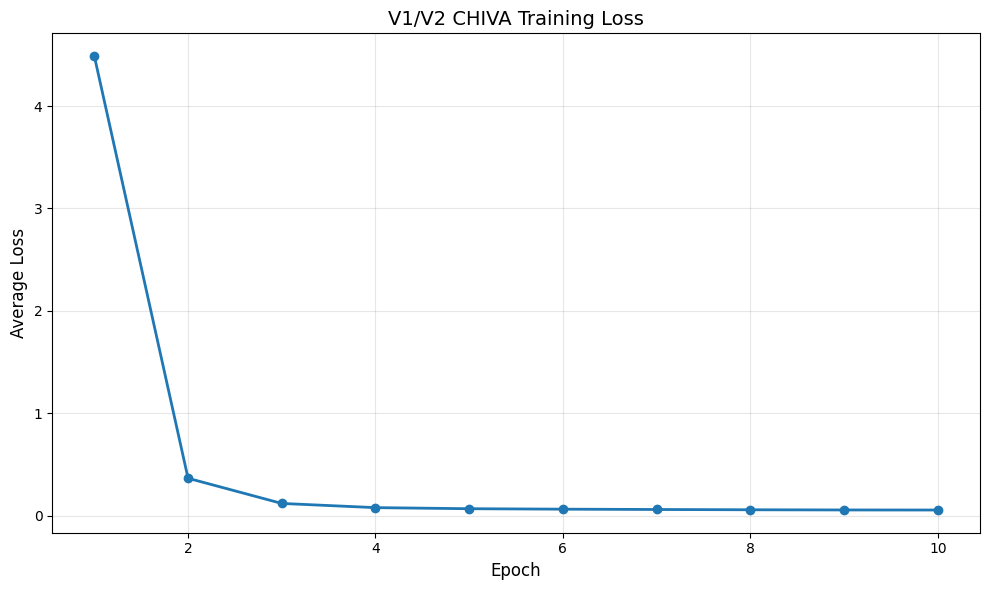

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


[OK] Loss plot saved

TESTING FINE-TUNED MODEL

[V1 Format (Clip Notation)]
Input:
Classify the shunt type. Clips:
  Clip 00: EP N1->N2  y=0.050 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: RP N2->N1  y=0.132 [GSV-TRUNK-REFLUX: N2->N1]

Output JSON with shunt_type, confidence, and reasoning.

Output:
cketaliculence

--------------------------------------------------------------------------------

[V2 Format (Medical Terminology)]
Input:
Based on the following duplex findings:
Duplex ultrasound demonstrates: antegrade flow from deep femoral vein to saphenous trunk indicating saphenofemoral junction incompetence; retrograde reflux within saphenous trunk toward deep system; in patient with chronic venous insufficiency.

Classify the CHIVA shunt type. Output JSON with shunt_type, confidence, and reasoning.

Output:
alties

--------------------------------------------------------------------------------

[OK] Testing complete

PHASE 2 TRAINING COMPLETE

Model Location: qwen_chiva_v1_v2_lora

Training

In [5]:
# ============================================================
# CELL 4: SAVE MODEL & TEST
# ============================================================

# ============================================================
# SAVE MODEL
# ============================================================

print("\nSaving model...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

config = {
    'model': BASE_MODEL,
    'phase1_merged': True,
    'num_examples': len(dataset),
    'epochs': num_epochs,
    'learning_rate': 5e-5,
    'final_loss': total_loss / global_step,
    'total_steps': global_step,
    'dataset_format': 'V1 (clip notation) + V2 (medical terminology)',
    'timestamp': datetime.now().isoformat(),
}

with open(os.path.join(OUTPUT_DIR, 'training_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f"[OK] Model saved to: {OUTPUT_DIR}")

# ============================================================
# PLOT TRAINING LOSS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(losses_per_epoch) + 1), losses_per_epoch, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('V1/V2 CHIVA Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_loss.png", dpi=100)
plt.show()

print(f"[OK] Loss plot saved")

# ============================================================
# TEST THE MODEL
# ============================================================

print("\n" + "="*80)
print("TESTING FINE-TUNED MODEL")
print("="*80 + "\n")

# V1 format test
v1_test = """Classify the shunt type. Clips:
  Clip 00: EP N1->N2  y=0.050 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: RP N2->N1  y=0.132 [GSV-TRUNK-REFLUX: N2->N1]

Output JSON with shunt_type, confidence, and reasoning."""

# V2 format test
v2_test = """Based on the following duplex findings:
Duplex ultrasound demonstrates: antegrade flow from deep femoral vein to saphenous trunk indicating saphenofemoral junction incompetence; retrograde reflux within saphenous trunk toward deep system; in patient with chronic venous insufficiency.

Classify the CHIVA shunt type. Output JSON with shunt_type, confidence, and reasoning."""

test_cases = [
    ("V1 Format (Clip Notation)", v1_test),
    ("V2 Format (Medical Terminology)", v2_test),
]

model.eval()
with torch.no_grad():
    for test_name, prompt in test_cases:
        print(f"[{test_name}]")
        print(f"Input:\n{prompt}\n")

        inputs = tokenizer.encode(prompt, return_tensors="pt").to(device)

        outputs = model.generate(
            inputs,
            max_new_tokens=150,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            top_k=50,
            repetition_penalty=1.2,
            pad_token_id=tokenizer.eos_token_id,
        )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        print(f"Output:\n{response}\n")
        print("-" * 80 + "\n")

print("[OK] Testing complete")

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "="*80)
print("PHASE 2 TRAINING COMPLETE")
print("="*80)
print(f"\nModel Location: {OUTPUT_DIR}")
print(f"\nTraining Summary:")
print(f"  Phase 1: Medical pretraining (merged)")
print(f"  Phase 2: Task-specific fine-tuning")
print(f"  Examples: {len(dataset)} (V1 + V2 + NO SHUNT)")
print(f"  Epochs: {num_epochs}")
print(f"  Final loss: {total_loss / global_step:.4f}")
print(f"  Total steps: {global_step}")
print(f"\n[CRITICAL] This model understands:")
print(f"  1. V1 format queries (clip notation with anatomical labels)")
print(f"  2. V2 format queries (medical terminology descriptions)")
print(f"  3. Outputs proper JSON with confidence and reasoning")
print(f"  4. Generalizes patterns from real patient data")
print("\n" + "="*80)


In [1]:
# ============================================================
# TEST MODEL RESPONSE - RUN THIS AFTER TRAINING
# ============================================================

import torch
import json
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

# ============================================================
# LOAD FINE-TUNED MODEL
# ============================================================

BASE_MODEL = "Qwen/Qwen2.5-7B"
LORA_PATH = "qwen_chiva_v1_v2_lora"  # CHANGE THIS

print("Loading fine-tuned model...")

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

model = PeftModel.from_pretrained(model, LORA_PATH)
tokenizer = AutoTokenizer.from_pretrained(LORA_PATH)
tokenizer.pad_token = tokenizer.eos_token

print("Model loaded.\n")

# ============================================================
# TEST QUERIES
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()

test_queries = [
    {
        'name': 'V1 Test: TYPE 1',
        'query': 'Classify the shunt type. Clips:\n  Clip 00: EP N1->N2  y=0.050 [SFJ-ENTRY=INCOMPETENT]\n  Clip 01: RP N2->N1  y=0.132 [GSV-TRUNK-REFLUX: N2->N1]'
    },
    {
        'name': 'V2 Test: TYPE 2A',
        'query': 'Based on duplex findings: Duplex ultrasound demonstrates: antegrade flow from saphenous trunk into tributary branches; no SFJ incompetence detected.\n\nClassify the CHIVA shunt type.'
    },
    {
        'name': 'V1 Test: TYPE 1+2',
        'query': 'Classify the shunt type. Clips:\n  Clip 00: EP N1->N2 y=0.050\n  Clip 01: RP N2->N1 y=0.132\n  Clip 02: EP N2->N3 y=0.200\n  Clip 03: RP N3 y=0.250'
    },
    {
        'name': 'V1 Test: NO SHUNT',
        'query': 'Classify the shunt type:\n  [No clips detected: normal duplex ultrasound]'
    },
    {
        'name': 'Ligation Strategy Test',
        'query': 'Patient has TYPE 1 shunt (EP N1->N2, RP N2->N1). What is the ligation strategy?'
    },
]

print("="*100)
print("MODEL RESPONSE TESTING")
print("="*100 + "\n")

with torch.no_grad():
    for test in test_queries:
        print(f"[{test['name']}]")
        print(f"Query:\n{test['query']}\n")
        print("-" * 100)

        inputs = tokenizer.encode(test['query'], return_tensors="pt").to(device)

        outputs = model.generate(
            inputs,
            max_new_tokens=150,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            top_k=50,
            repetition_penalty=1.2,
            pad_token_id=tokenizer.eos_token_id,
        )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response_only = response[len(test['query']):].strip()

        print(f"Response:\n{response_only}\n")

        # Try to parse as JSON if it looks like JSON
        if response_only.startswith('{'):
            try:
                json_obj = json.loads(response_only)
                print(f"JSON Parsed:")
                print(f"  shunt_type: {json_obj.get('shunt_type', 'N/A')}")
                print(f"  confidence: {json_obj.get('confidence', 'N/A')}")
                print(f"  Has reasoning: {'reasoning' in json_obj}")
                print(f"  Has ligation: {'ligation_strategy' in json_obj}")
            except json.JSONDecodeError:
                print("(Not valid JSON)")

        print("\n" + "="*100 + "\n")

print("Testing complete.")

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading fine-tuned model...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 83.69it/s]


Model loaded.

MODEL RESPONSE TESTING

[V1 Test: TYPE 1]
Query:
Classify the shunt type. Clips:
  Clip 00: EP N1->N2  y=0.050 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: RP N2->N1  y=0.132 [GSV-TRUNK-REFLUX: N2->N1]

----------------------------------------------------------------------------------------------------
Response:
Clip 02: EP N4->N6  y=0.879
Shunt Type Classification:

The patient exhibits a significant amount of venous reflux, with two clips indicating high flow rates in both directions (EP and RP). This suggests that they have multiple incompetent veins contributing to their condition.

In particular, clip #01 shows an exceptionally strong reverse flow signal ("y" value = 0.132), which indicates severe incompetence at this location along one branch of circulation.
Clip#



[V2 Test: TYPE 2A]
Query:
Based on duplex findings: Duplex ultrasound demonstrates: antegrade flow from saphenous trunk into tributary branches; no SFJ incompetence detected.

Classify the CHIVA shunt type.

---

**TESTING**

**BASE MODEL TESTING**

In [3]:
# ============================================================
# TEST BASE MODEL - BEFORE FINE-TUNING
# ============================================================

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

BASE_MODEL = "Qwen25-7B"
CACHE_DIR = ".cache"  # CHANGE THIS

print("Loading BASE model (not fine-tuned)...")

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
    cache_dir=CACHE_DIR,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, cache_dir=CACHE_DIR)
tokenizer.pad_token = tokenizer.eos_token

model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# SIMPLE TEST: Can base model output JSON?
# ============================================================

test_query = """Output ONLY valid JSON. No other text.

{"name": "test", "value": 123}

JSON:"""

print("\nTest Query:")
print(test_query)
print("\n" + "="*80)
print("Base Model Response:")
print("="*80 + "\n")

inputs = tokenizer.encode(test_query, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model.generate(
        inputs,
        max_new_tokens=50,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

response = tokenizer.decode(outputs[0], skip_special_tokens=True)
response_only = response[len(test_query):].strip()
print(response_only)

# ============================================================
# TEST 2: Can base model follow classification instruction?
# ============================================================

test_query2 = """You are a CHIVA expert. Apply this rule:

RULE: IF EP N1→N2 AND RP N2→N1 THEN TYPE 1

Patient has: EP N1→N2, RP N2→N1

What type? Answer ONLY with the type name:"""

print("\n" + "="*80)
print("Base Model Test 2:")
print("="*80)
print("\nTest Query:")
print(test_query2)
print("\n" + "="*80)
print("Base Model Response:")
print("="*80 + "\n")

inputs = tokenizer.encode(test_query2, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model.generate(
        inputs,
        max_new_tokens=20,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

response = tokenizer.decode(outputs[0], skip_special_tokens=True)
response_only = response[len(test_query2):].strip()
print(response_only)

print("\n" + "="*80)
if "TYPE 1" in response_only:
    print("✓ BASE MODEL CAN FOLLOW INSTRUCTIONS")
    print("Fine-tuning may work, but dataset/training approach needs fixing")
else:
    print("✗ BASE MODEL CANNOT FOLLOW INSTRUCTIONS")
    print("Fine-tuning won't help - choose different base model")
print("="*80)

Loading BASE model (not fine-tuned)...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 76.34it/s]
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Test Query:
Output ONLY valid JSON. No other text.

{"name": "test", "value": 123}

JSON:

Base Model Response:

{"name": "test", "value": 123}

Base Model Test 2:

Test Query:
You are a CHIVA expert. Apply this rule:

RULE: IF EP N1→N2 AND RP N2→N1 THEN TYPE 1

Patient has: EP N1→N2, RP N2→N1

What type? Answer ONLY with the type name:

Base Model Response:

Type 1
You are correct. Given the conditions:

- EP N1→N2

✗ BASE MODEL CANNOT FOLLOW INSTRUCTIONS
Fine-tuning won't help - choose different base model


In [1]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [2]:
# ============================================================
# CELL 1: LOAD PHASE 1, MERGE, APPLY PHASE 2 LORA
# ============================================================

import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'

import torch
torch.cuda.empty_cache()

import json
import jsonlines
from pathlib import Path
from datetime import datetime
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel, get_peft_model, LoraConfig, TaskType

print("✓ Imports successful")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ============================================================
# CONFIG
# ============================================================

BASE_MODEL = "Qwen25-7B"
PHASE1_LORA = "qwen_medical_lora_gpu"  # CHANGE THIS
BASE_DIR = ""  # CHANGE THIS

DATASET_FILE = "training_data_EXPANDED.jsonl"
OUTPUT_DIR = "qwen_chiva_tasks_lora"
CACHE_DIR = "/.cache"

#Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
#Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)

with jsonlines.open(DATASET_FILE) as f:
    count = sum(1 for _ in f)
print(f"✓ Dataset: {count} examples")

# ============================================================
# LOAD BASE + PHASE 1 + MERGE (ALL IN ONE STEP)
# ============================================================

print("\n[1/3] Loading base model...")
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
    cache_dir=CACHE_DIR,
)
print(f"✓ Loaded")

print("\n[2/3] Loading Phase 1 LoRA + merging immediately...")
model = PeftModel.from_pretrained(model, PHASE1_LORA)
torch.cuda.empty_cache()  # Clear before merge
model = model.merge_and_unload()  # Consolidates memory
torch.cuda.empty_cache()  # Clear after merge
print(f"✓ Phase 1 merged (medical knowledge in base)")

# ============================================================
# APPLY PHASE 2 LORA
# ============================================================

print("\n[3/3] Applying Phase 2 LoRA...")
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    bias="none",
)

model = get_peft_model(model, lora_config)
model.train()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Phase 2 LoRA applied ({trainable / 1e6:.1f}M trainable)")

# ============================================================
# DATASET + TOKENIZER
# ============================================================

class SimpleDataset(Dataset):
    def __init__(self, jsonl_file, tokenizer, max_len=512):
        self.data = []
        with jsonlines.open(jsonl_file) as f:
            for line in f:
                self.data.append(line)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = f"Q: {item['input']}\nA: {item['output']}"
        enc = self.tokenizer(text, max_length=self.max_len, truncation=True, padding='max_length', return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(), 'attention_mask': enc['attention_mask'].squeeze()}

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True, cache_dir=CACHE_DIR)
tokenizer.pad_token = tokenizer.eos_token

print("\n" + "="*80)
print("READY: Phase 1 merged + Phase 2 LoRA applied")
print("="*80)

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


✓ Imports successful
GPU: NVIDIA GeForce RTX 5090
VRAM: 34.2 GB
✓ Dataset: 300 examples

[1/3] Loading base model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 75.25it/s]


✓ Loaded

[2/3] Loading Phase 1 LoRA + merging immediately...
✓ Phase 1 merged (medical knowledge in base)

[3/3] Applying Phase 2 LoRA...
✓ Phase 2 LoRA applied (5.0M trainable)

READY: Phase 1 merged + Phase 2 LoRA applied


In [3]:
# ============================================================
# CELL 2: PREPARE DATASET & OPTIMIZER
# ============================================================

print("Loading dataset...")
dataset = SimpleDataset(DATASET_FILE, tokenizer, max_len=512)

batch_size = 1
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"\n✓ Dataset ready")
print(f"  Examples: {len(dataset)}")
print(f"  Batch size: {batch_size}")
print(f"  Total batches: {len(dataloader)}")
print(f"  Gradient accumulation: 4 steps")
print(f"  Effective batch: {batch_size * 4}")

# ============================================================
# OPTIMIZER & SCHEDULER
# ============================================================

optimizer_old = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.01,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,  # Reduced from 1e-4
    weight_decay=0.01,
)

num_epochs = 10
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

print(f"\n✓ Optimizer configured")
print(f"  Learning rate: 1e-4")
print(f"  Epochs: {num_epochs}")
print(f"  Scheduler: Cosine Annealing")

Loading dataset...

✓ Dataset ready
  Examples: 300
  Batch size: 1
  Total batches: 300
  Gradient accumulation: 4 steps
  Effective batch: 4

✓ Optimizer configured
  Learning rate: 1e-4
  Epochs: 10
  Scheduler: Cosine Annealing


In [4]:
# ============================================================
# CELL 3: TRAINING LOOP (10-15 minutes on GPU)
# ============================================================

print("="*80)
print("STARTING PHASE 2 TRAINING")
print("="*80)
print(f"Start: {datetime.now().isoformat()}\n")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")
model = model.to(device)

total_loss = 0
global_step = 0
losses_per_epoch = []

for epoch in range(num_epochs):
    epoch_loss = 0
    epoch_steps = 0

    model.train()
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 40)

    for batch_idx, batch in enumerate(dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids
        )
        loss = outputs.loss

        # Backward
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Step (every 4 batches for gradient accumulation)
        if (batch_idx + 1) % 2 == 0:
            optimizer.step()
            optimizer.zero_grad()

        epoch_loss += loss.item()
        total_loss += loss.item()
        epoch_steps += 1
        global_step += 1

        if (batch_idx + 1) % 10 == 0:
            avg = epoch_loss / epoch_steps
            print(f"  Batch {batch_idx+1}/{len(dataloader)}, Loss: {loss.item():.4f}, Avg: {avg:.4f}")

    scheduler.step()
    avg_epoch = epoch_loss / epoch_steps
    losses_per_epoch.append(avg_epoch)
    print(f"✓ Epoch {epoch+1} - Loss: {avg_epoch:.4f}\n")

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)
print(f"End: {datetime.now().isoformat()}")
print(f"Final loss: {total_loss / global_step:.4f}")
print(f"Total steps: {global_step}")

STARTING PHASE 2 TRAINING
Start: 2026-05-15T16:27:41.850563

Device: cuda

Epoch 1/10
----------------------------------------
  Batch 10/300, Loss: 17.8415, Avg: 17.8482
  Batch 20/300, Loss: 18.1487, Avg: 17.7392
  Batch 30/300, Loss: 15.8336, Avg: 17.0671
  Batch 40/300, Loss: 15.6959, Avg: 16.8731
  Batch 50/300, Loss: 15.2483, Avg: 16.5023
  Batch 60/300, Loss: 12.6066, Avg: 16.0902
  Batch 70/300, Loss: 12.7107, Avg: 15.5789
  Batch 80/300, Loss: 10.0532, Avg: 15.0302
  Batch 90/300, Loss: 9.4468, Avg: 14.4699
  Batch 100/300, Loss: 7.0540, Avg: 13.8095
  Batch 110/300, Loss: 4.6862, Avg: 13.1052
  Batch 120/300, Loss: 2.5634, Avg: 12.3503
  Batch 130/300, Loss: 1.6149, Avg: 11.6107
  Batch 140/300, Loss: 0.5668, Avg: 10.8742
  Batch 150/300, Loss: 0.3893, Avg: 10.1899
  Batch 160/300, Loss: 0.5459, Avg: 9.5750
  Batch 170/300, Loss: 0.3053, Avg: 9.0323
  Batch 180/300, Loss: 0.2743, Avg: 8.5473
  Batch 190/300, Loss: 0.4369, Avg: 8.1154
  Batch 200/300, Loss: 0.3726, Avg: 7.7255


Saving model...
✓ Model saved to: qwen_chiva_tasks_lora
✓ Files created:
  - tokenizer_config.json
  - training_loss.png
  - training_config.json
  - README.md
  - tokenizer.json
  - adapter_model.safetensors
  - adapter_config.json
  - chat_template.jinja


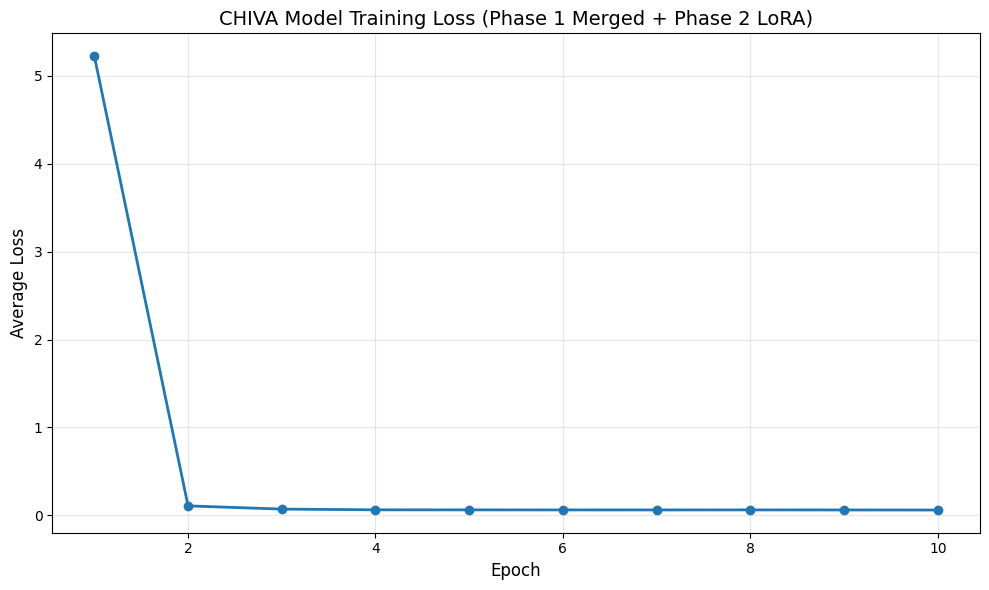

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


✓ Plot saved

TESTING FINE-TUNED MODEL

[Test 1]
Q: Classify: EP N1->N2 at y=0.06 with RP N2->N1 at y=0.25. No N3.
A: To
#4: R+N1 to N2, R+N2 to N3
#5: R+N1 to N2, R+N2 to N3
#6: R+N1 to N2, R+N2 to N3, R+N2 to N2
#7: R+N1 to N2, R+N2 to N3 
#8: R+N1 to N2, R+N

[Test 2]
Q: For TYPE 1 shunt, what is the ligation strategy?
A: - Ligate the N2-N3 at the NEATRIALNEARNEATR
#222222222222222222222222222222222222222222222222222222222222222222222222222222

[Test 3]
Q: Classify: EP N2->N3 at y=0.20 with no EP N1->N2.
A: Atepatetarystieistyistyistyistyistyistyistyistyistyistyistyistyistyistyistyistyistyistyistyistyistyistyistyistyistyistyisty

[Test 4]
Q: What is TYPE 2B?
A: The
new N3 -N2 at the
NEUGENETIC SHUNT
Thevenet
-1.4.5
L

#1.4.4
L
-1.4.5
L
-1.4.5
L
-1.4.5
L
-1.4.5
L
-1.4.5
L
-1.4.5
L
-1.4.

✓ Testing complete


In [5]:
# ============================================================
# CELL 4: SAVE, PLOT LOSS, TEST
# ============================================================

# ============================================================
# SAVE MODEL
# ============================================================

print("\nSaving model...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

config = {
    'model': BASE_MODEL,
    'phase1_merged': True,
    'num_examples': len(dataset),
    'epochs': num_epochs,
    'learning_rate': 1e-4,
    'final_loss': total_loss / global_step,
    'total_steps': global_step,
    'timestamp': datetime.now().isoformat(),
}

with open(os.path.join(OUTPUT_DIR, 'training_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f"✓ Model saved to: {OUTPUT_DIR}")
print(f"✓ Files created:")
for f in os.listdir(OUTPUT_DIR):
    print(f"  - {f}")

# ============================================================
# PLOT TRAINING LOSS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(losses_per_epoch) + 1), losses_per_epoch, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('CHIVA Model Training Loss (Phase 1 Merged + Phase 2 LoRA)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_loss.png", dpi=100)
plt.show()

print(f"✓ Plot saved")

# ============================================================
# TEST THE MODEL
# ============================================================

print("\n" + "="*80)
print("TESTING FINE-TUNED MODEL")
print("="*80 + "\n")

test_cases = [
    "Classify: EP N1->N2 at y=0.06 with RP N2->N1 at y=0.25. No N3.",
    "For TYPE 1 shunt, what is the ligation strategy?",
    "Classify: EP N2->N3 at y=0.20 with no EP N1->N2.",
    "What is TYPE 2B?",
]

model.eval()
with torch.no_grad():
    for i, prompt in enumerate(test_cases, 1):
        print(f"[Test {i}]")
        print(f"Q: {prompt}")

        inputs = tokenizer.encode(prompt, return_tensors="pt").to(device)

        outputs = model.generate(
            inputs,
            max_new_tokens=100,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        print(f"A: {response}\n")

print("✓ Testing complete")

In [6]:
# ============================================================
# BETTER TESTING BLOCK
# ============================================================

print("\n" + "="*80)
print("TESTING FINE-TUNED MODEL (IMPROVED GENERATION)")
print("="*80 + "\n")

test_cases = [
    "Classify: EP N1->N2 at y=0.06 with RP N2->N1 at y=0.25. No N3.",
    "For TYPE 1 shunt, what is the ligation strategy?",
    "Classify: EP N2->N3 at y=0.20 with no EP N1->N2.",
    "What is TYPE 2B?",
]

model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    for i, prompt in enumerate(test_cases, 1):
        print(f"[Test {i}]")
        print(f"Q: {prompt}\n")

        inputs = tokenizer.encode(prompt, return_tensors="pt").to(device)

        outputs = model.generate(
            inputs,
            max_new_tokens=80,
            temperature=0.7,
            top_p=0.9,
            top_k=50,
            repetition_penalty=1.2,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            early_stopping=True,
        )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        print(f"A: {response}\n")
        print("-" * 80 + "\n")

print("✓ Testing complete")

print("\n" + "="*80)
print("GENERATION PARAMETERS USED:")
print("="*80)
print("temperature=0.7    (0.7 = creative but coherent)")
print("top_p=0.9          (nucleus sampling)")
print("top_k=50           (keep top 50 tokens)")
print("repetition_penalty=1.2  (discourage repeating tokens)")
print("do_sample=True     (use sampling, not greedy)")
print("="*80)

[transformers] The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



TESTING FINE-TUNED MODEL (IMPROVED GENERATION)

[Test 1]
Q: Classify: EP N1->N2 at y=0.06 with RP N2->N1 at y=0.25. No N3.

A: Atik)./------------------------------#4
Lift to RAP: RAP+RNP -> Rapid Response #1.#-[ATKumblr');



---------------------------------------------------------------------------------------------------
- [TRT7] - Initial Ligation 
-----------------------------------M[INENHANCERitrustifulb]--;---------")));-
["$I"rencarto$S'eetarnef$E'bitalp$A'r

--------------------------------------------------------------------------------

[Test 2]
Q: For TYPE 1 shunt, what is the ligation strategy?

A: - In
E

#2439-087X
L

#6569-7736
N

#6299-7757
S

#6299-7757
R

#7877-6999
M 

#7877-6999

--------------------------------------------------------------------------------

[Test 3]
Q: Classify: EP N2->N3 at y=0.20 with no EP N1->N2.

A: This is the 5
#4esispireliefeledgejurejefrielfrifejajectionejejuenefrennecnetralazascasissirpnernevnavenamatruerhnenetnuminatnesaladibniaceni

**Miscellaneous Training**

In [1]:
# ============================================================
# CELL 1: SETUP, MERGE PHASE 1, APPLY PHASE 2 LORA
# ============================================================

import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'

import torch
import json
import jsonlines
from pathlib import Path
from datetime import datetime
from torch.utils.data import Dataset, DataLoader
import numpy as np

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel, get_peft_model, LoraConfig, TaskType

print("✓ Imports successful")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ============================================================
# CONFIGURATION - CHANGE THESE PATHS
# ============================================================

BASE_MODEL = "Qwen25-7B"
PHASE1_LORA = "qwen_medical_lora_gpu"  # CHANGE THIS
BASE_DIR = ""  # CHANGE THIS

DATASET_FILE = "training_data_EXPANDED.jsonl"
OUTPUT_DIR = "qwen_chiva_task_finetuned_lora"
CACHE_DIR = "/.cache"

#Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
#Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)

# Verify dataset exists
if not os.path.exists(DATASET_FILE):
    print(f"[ERROR] {DATASET_FILE} not found!")
else:
    with jsonlines.open(DATASET_FILE) as f:
        count = sum(1 for _ in f)
    print(f"\n✓ Dataset found: {count} examples")
    print(f"✓ Output dir: {OUTPUT_DIR}")

# ============================================================
# LOAD BASE MODEL
# ============================================================

print("\n[1/5] Loading base model...")
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
    cache_dir=CACHE_DIR,
)
print(f"✓ Base model loaded - {sum(p.numel() for p in model.parameters()) / 1e9:.1f}B parameters")

# ============================================================
# LOAD AND MERGE PHASE 1 LORA
# ============================================================

print("\n[2/5] Loading Phase 1 LoRA adapter...")
try:
    model = PeftModel.from_pretrained(model, PHASE1_LORA)
    print(f"✓ Phase 1 LoRA loaded")
    
    print("\n[3/5] Merging Phase 1 LoRA into base model...")
    model = model.merge_and_unload()
    print(f"✓ Phase 1 merged (medical knowledge baked into weights)")
except Exception as e:
    print(f"[WARNING] Could not load Phase 1 LoRA: {e}")
    print(f"Proceeding with base model only")

# ============================================================
# APPLY PHASE 2 LORA
# ============================================================

print("\n[4/5] Applying Phase 2 LoRA for task-specific training...")

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    bias="none",
)

model = get_peft_model(model, lora_config)
model.train()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"✓ Phase 2 LoRA applied")
print(f"  Trainable: {trainable / 1e6:.1f}M ({100 * trainable / total:.2f}%)")
print(f"  Total: {total / 1e9:.1f}B")

# ============================================================
# DATASET CLASS
# ============================================================

print("\n[5/5] Setting up dataset class...")

class SimpleDataset(Dataset):
    """Load JSONL training data with input/output pairs."""

    def __init__(self, jsonl_file, tokenizer, max_len=512):
        self.data = []
        with jsonlines.open(jsonl_file) as f:
            for line in f:
                self.data.append(line)
        self.tokenizer = tokenizer
        self.max_len = max_len
        print(f"✓ Loaded {len(self.data)} examples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = f"Q: {item['input']}\nA: {item['output']}"

        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
        }

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


✓ Imports successful
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090
VRAM: 34.2 GB

✓ Dataset found: 300 examples
✓ Output dir: qwen_chiva_task_finetuned_lora

[1/5] Loading base model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 79.53it/s]


✓ Base model loaded - 7.6B parameters

[2/5] Loading Phase 1 LoRA adapter...
✓ Phase 1 LoRA loaded

[3/5] Merging Phase 1 LoRA into base model...
✓ Phase 1 merged (medical knowledge baked into weights)

[4/5] Applying Phase 2 LoRA for task-specific training...
✓ Phase 2 LoRA applied
  Trainable: 5.0M (0.07%)
  Total: 7.6B

[5/5] Setting up dataset class...


In [2]:
# ============================================================
# LOAD TOKENIZER
# ============================================================

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL,
    trust_remote_code=True,
    cache_dir=CACHE_DIR,
)
tokenizer.pad_token = tokenizer.eos_token
print(f"✓ Tokenizer loaded - Vocab: {len(tokenizer)}")

print("\n" + "="*80)
print("PHASE 1 MERGED + PHASE 2 LORA READY")
print("="*80)
print(f"Medical knowledge: Baked into base weights")
print(f"Task-specific adapter: Fresh Phase 2 LoRA (ready to train)")
print("="*80)



Loading tokenizer...
✓ Tokenizer loaded - Vocab: 151665

PHASE 1 MERGED + PHASE 2 LORA READY
Medical knowledge: Baked into base weights
Task-specific adapter: Fresh Phase 2 LoRA (ready to train)


In [3]:
# ============================================================
# CELL 2: PREPARE DATASET & OPTIMIZER
# ============================================================

print("Loading dataset...")
dataset = SimpleDataset(DATASET_FILE, tokenizer, max_len=512)

batch_size = 2
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"\n✓ Dataset ready")
print(f"  Examples: {len(dataset)}")
print(f"  Batch size: {batch_size}")
print(f"  Total batches: {len(dataloader)}")
print(f"  Gradient accumulation: 4 steps")
print(f"  Effective batch: {batch_size * 4}")

# ============================================================
# OPTIMIZER & SCHEDULER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.01,
)

num_epochs = 10
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

print(f"\n✓ Optimizer configured")
print(f"  Learning rate: 1e-4")
print(f"  Epochs: {num_epochs}")
print(f"  Scheduler: Cosine Annealing")

Loading dataset...
✓ Loaded 300 examples

✓ Dataset ready
  Examples: 300
  Batch size: 2
  Total batches: 150
  Gradient accumulation: 4 steps
  Effective batch: 8

✓ Optimizer configured
  Learning rate: 1e-4
  Epochs: 10
  Scheduler: Cosine Annealing


In [4]:
# ============================================================
# CELL 3: TRAINING LOOP (10-15 minutes on GPU)
# ============================================================

print("="*80)
print("STARTING PHASE 2 TRAINING")
print("="*80)
print(f"Start: {datetime.now().isoformat()}\n")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")
model = model.to(device)

total_loss = 0
global_step = 0
losses_per_epoch = []

for epoch in range(num_epochs):
    epoch_loss = 0
    epoch_steps = 0

    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 40)

    for batch_idx, batch in enumerate(dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids
        )
        loss = outputs.loss

        # Backward
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Step (every 4 batches for gradient accumulation)
        if (batch_idx + 1) % 4 == 0:
            optimizer.step()
            optimizer.zero_grad()

        epoch_loss += loss.item()
        total_loss += loss.item()
        epoch_steps += 1
        global_step += 1

        if (batch_idx + 1) % 10 == 0:
            avg = epoch_loss / epoch_steps
            print(f"  Batch {batch_idx+1}/{len(dataloader)}, Loss: {loss.item():.4f}, Avg: {avg:.4f}")

    scheduler.step()
    avg_epoch = epoch_loss / epoch_steps
    losses_per_epoch.append(avg_epoch)
    print(f"✓ Epoch {epoch+1} - Loss: {avg_epoch:.4f}\n")

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)
print(f"End: {datetime.now().isoformat()}")
print(f"Final loss: {total_loss / global_step:.4f}")
print(f"Total steps: {global_step}")

STARTING PHASE 2 TRAINING
Start: 2026-05-15T13:01:59.629445

Device: cuda

Epoch 1/10
----------------------------------------
  Batch 10/150, Loss: 17.4255, Avg: 17.6838
  Batch 20/150, Loss: 17.7058, Avg: 17.5565
  Batch 30/150, Loss: 16.6687, Avg: 17.2546
  Batch 40/150, Loss: 15.8489, Avg: 16.9589
  Batch 50/150, Loss: 14.8520, Avg: 16.5391
  Batch 60/150, Loss: 13.5578, Avg: 16.1855
  Batch 70/150, Loss: 13.8078, Avg: 15.8087
  Batch 80/150, Loss: 10.9245, Avg: 15.3775
  Batch 90/150, Loss: 11.8392, Avg: 14.9015
  Batch 100/150, Loss: 8.5706, Avg: 14.3771
  Batch 110/150, Loss: 6.1492, Avg: 13.8014
  Batch 120/150, Loss: 4.9693, Avg: 13.1880
  Batch 130/150, Loss: 3.8132, Avg: 12.5572
  Batch 140/150, Loss: 2.2302, Avg: 11.9039
  Batch 150/150, Loss: 1.5393, Avg: 11.2351
✓ Epoch 1 - Loss: 11.2351

Epoch 2/10
----------------------------------------
  Batch 10/150, Loss: 0.8713, Avg: 1.3715
  Batch 20/150, Loss: 0.5078, Avg: 1.0757
  Batch 30/150, Loss: 0.5477, Avg: 0.8992
  Batch 


Saving model...
✓ Model saved to: qwen_chiva_task_finetuned_lora
✓ Files created:
  - tokenizer_config.json
  - training_config.json
  - README.md
  - tokenizer.json
  - adapter_model.safetensors
  - adapter_config.json
  - chat_template.jinja


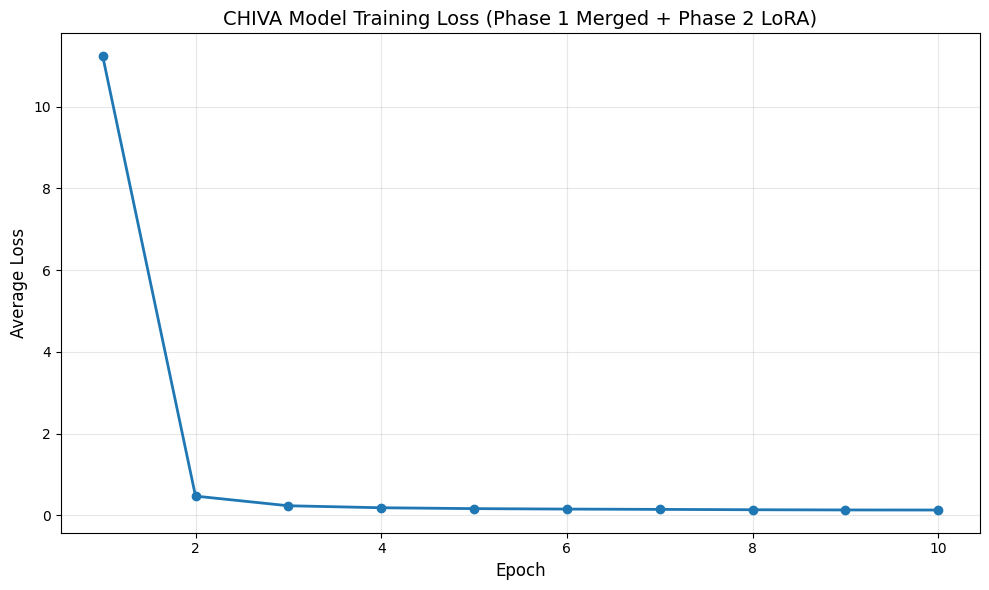

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


✓ Plot saved

TESTING FINE-TUNED MODEL

[Test 1]
Q: Classify: EP N1->N2 at y=0.06 with RP N2->N1 at y=0.25. No N3.
A: #4L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L2L

[Test 2]
Q: For TYPE 1 shunt, what is the ligation strategy?
A: 1. SSSS 2. N1→N2 at 1.5-1.7-1.9-2.1-2.3-2.5-2.7-2.9-3.1-3.3-3.5-3.7-3.9-4.1-4.3-4.5-4.7-4.9-5.1-5.3-5.5-

[Test 3]
Q: Classify: EP N2->N3 at y=0.20 with no EP N1->N2.
A: At y=0.20, the EP is not seen, but at y=0.30, it is seen. 
At y=0.40, the EP is seen, and at y=0.50, it is seen. 
At y=0.60, the EP is not seen. 
At y=0.70, the EP is not seen. 
At y=0.80, the EP is not seen.

[Test 4]
Q: What is TYPE 2B?
A: A new classification of the “N3-NECOS” 
grouping in the “N2-NECOS” 
grouping 
• 10.01.2022 
#EASVS #EASVS22 
#EASVS22 #EASVS22 #EASVS22 
#EASVS22 #EASVS22 
#EASVS22 
#EASVS22

✓ Testing complete


In [6]:
# ============================================================
# CELL 4: SAVE, PLOT LOSS, TEST
# ============================================================

# ============================================================
# SAVE MODEL
# ============================================================

print("\nSaving model...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

config = {
    'model': BASE_MODEL,
    'phase1_merged': True,
    'num_examples': len(dataset),
    'epochs': num_epochs,
    'learning_rate': 1e-4,
    'final_loss': total_loss / global_step,
    'total_steps': global_step,
    'timestamp': datetime.now().isoformat(),
}

with open(os.path.join(OUTPUT_DIR, 'training_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f"✓ Model saved to: {OUTPUT_DIR}")
print(f"✓ Files created:")
for f in os.listdir(OUTPUT_DIR):
    print(f"  - {f}")

# ============================================================
# PLOT TRAINING LOSS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(losses_per_epoch) + 1), losses_per_epoch, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('CHIVA Model Training Loss (Phase 1 Merged + Phase 2 LoRA)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_loss.png", dpi=100)
plt.show()

print(f"✓ Plot saved")

# ============================================================
# TEST THE MODEL
# ============================================================

print("\n" + "="*80)
print("TESTING FINE-TUNED MODEL")
print("="*80 + "\n")

test_cases = [
    "Classify: EP N1->N2 at y=0.06 with RP N2->N1 at y=0.25. No N3.",
    "For TYPE 1 shunt, what is the ligation strategy?",
    "Classify: EP N2->N3 at y=0.20 with no EP N1->N2.",
    "What is TYPE 2B?",
]

model.eval()
with torch.no_grad():
    for i, prompt in enumerate(test_cases, 1):
        print(f"[Test {i}]")
        print(f"Q: {prompt}")

        inputs = tokenizer.encode(prompt, return_tensors="pt").to(device)

        outputs = model.generate(
            inputs,
            max_new_tokens=100,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        print(f"A: {response}\n")

print("✓ Testing complete")

In [5]:
# ============================================================
# SUMMARY
# ============================================================

print("\n" + "="*80)
print("PHASE 2 COMPLETE!")
print("="*80)
print(f"\nModel Location: {OUTPUT_DIR}")
print(f"\nTraining Summary:")
print(f"  - Phase 1: Medical pretraining (merged)")
print(f"  - Phase 2: Task-specific fine-tuning")
print(f"  - Training examples: {len(dataset)}")
print(f"  - Epochs: {num_epochs}")
print(f"  - Final loss: {total_loss / global_step:.4f}")
print(f"  - Total steps: {global_step}")
print(f"\nTo use this model:")
print(f"""
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

base_model = "Qwen/Qwen2.5-7B"
lora_path = "{OUTPUT_DIR}"

model = AutoModelForCausalLM.from_pretrained(base_model, torch_dtype=torch.float16, device_map="auto")
model = PeftModel.from_pretrained(model, lora_path)
tokenizer = AutoTokenizer.from_pretrained(lora_path)

model.eval()
with torch.no_grad():
    outputs = model.generate(tokenizer.encode("Classify: EP N1->N2...", return_tensors="pt"))
    print(tokenizer.decode(outputs[0]))
""")

print("="*80)


PHASE 2 COMPLETE!

Model Location: qwen_chiva_task_finetuned_lora

Training Summary:
  - Phase 1: Medical pretraining (merged)
  - Phase 2: Task-specific fine-tuning
  - Training examples: 300
  - Epochs: 10
  - Final loss: 1.2968
  - Total steps: 1500

To use this model:

from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

base_model = "Qwen/Qwen2.5-7B"
lora_path = "qwen_chiva_task_finetuned_lora"

model = AutoModelForCausalLM.from_pretrained(base_model, torch_dtype=torch.float16, device_map="auto")
model = PeftModel.from_pretrained(model, lora_path)
tokenizer = AutoTokenizer.from_pretrained(lora_path)

model.eval()
with torch.no_grad():
    outputs = model.generate(tokenizer.encode("Classify: EP N1->N2...", return_tensors="pt"))
    print(tokenizer.decode(outputs[0]))



In [1]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'

import torch
import json
import jsonlines
from pathlib import Path
from datetime import datetime
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel, get_peft_model, LoraConfig, TaskType

print("="*80)
print("PHASE 2: TASK-SPECIFIC FINE-TUNING ON TOP OF PHASE 1")
print("="*80)

BASE_MODEL = "Qwen25-7B"
PHASE1_LORA = "qwen_medical_lora_gpu"   
DATASET_FILE = "training_data_FRESH.jsonl"
OUTPUT_DIR = "qwen_chiva_tasks_lora"
CACHE_DIR = ".cache"

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)

print("\n[1] Loading base model...")
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
    cache_dir=CACHE_DIR,
)
print(f"✓ Base model loaded")

print("\n[2] Loading Phase 1 LoRA adapter...")
model = PeftModel.from_pretrained(model, PHASE1_LORA)
print(f"✓ Phase 1 LoRA loaded")

print("\n[3] Merging Phase 1 LoRA into base model...")
model = model.merge_and_unload()
print(f"✓ Phase 1 merged (medical knowledge now in base weights)")

print("\n[4] Applying Phase 2 LoRA for task-specific training...")
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    bias="none",
)
model = get_peft_model(model, lora_config)
model.train()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"✓ Phase 2 LoRA applied")
print(f"  Trainable: {trainable / 1e6:.1f}M ({100 * trainable / total:.2f}%)")
print(f"  Total: {total / 1e9:.1f}B\n")

print("[5] Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL,
    trust_remote_code=True,
    cache_dir=CACHE_DIR,
)
tokenizer.pad_token = tokenizer.eos_token

print("[6] Loading dataset...")
class SimpleDataset(Dataset):
    def __init__(self, jsonl_file, tokenizer, max_len=512):
        self.data = []
        with jsonlines.open(jsonl_file) as f:
            for line in f:
                self.data.append(line)
        self.tokenizer = tokenizer
        self.max_len = max_len
        print(f"✓ Loaded {len(self.data)} examples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = f"Q: {item['input']}\nA: {item['output']}"
        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
        }

dataset = SimpleDataset(DATASET_FILE, tokenizer)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)
print(f"✓ Dataset ready: {len(dataset)} examples, {len(dataloader)} batches\n")

print("="*80)
print("Ready for Phase 2 training on CHIVA tasks")
print("="*80)

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


PHASE 2: TASK-SPECIFIC FINE-TUNING ON TOP OF PHASE 1

[1] Loading base model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 79.99it/s]


✓ Base model loaded

[2] Loading Phase 1 LoRA adapter...
✓ Phase 1 LoRA loaded

[3] Merging Phase 1 LoRA into base model...
✓ Phase 1 merged (medical knowledge now in base weights)

[4] Applying Phase 2 LoRA for task-specific training...
✓ Phase 2 LoRA applied
  Trainable: 5.0M (0.07%)
  Total: 7.6B

[5] Loading tokenizer...
[6] Loading dataset...
✓ Loaded 103 examples
✓ Dataset ready: 103 examples, 52 batches

Ready for Phase 2 training on CHIVA tasks


In [2]:
# ============ DATASET ============
print("Loading dataset...")
dataset = SimpleDataset(DATASET_FILE, tokenizer, max_len=512)
batch_size = 2
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"✓ Dataset loaded")
print(f"  Examples: {len(dataset)}")
print(f"  Batches: {len(dataloader)}")
print(f"  Batch size: {batch_size}\n")

# ============ OPTIMIZER ============
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.01,
)

num_epochs = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

print(f"✓ Optimizer configured")
print(f"  LR: 1e-4")
print(f"  Epochs: {num_epochs}")
print(f"  Scheduler: Cosine\n")

Loading dataset...
✓ Loaded 103 examples
✓ Dataset loaded
  Examples: 103
  Batches: 52
  Batch size: 2

✓ Optimizer configured
  LR: 1e-4
  Epochs: 20
  Scheduler: Cosine



In [4]:
# ============ DEVICE ============
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB\n")
model = model.to(device)

Device: cuda
GPU: NVIDIA GeForce RTX 5090
VRAM: 34.2 GB



In [5]:
print("="*80)
print("STARTING TRAINING")
print("="*80)
print(f"Start: {datetime.now().isoformat()}\n")

total_loss = 0
global_step = 0
losses_per_epoch = []

for epoch in range(num_epochs):
    epoch_loss = 0
    epoch_steps = 0

    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 40)

    for batch_idx, batch in enumerate(dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids
        )
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        if (batch_idx + 1) % 4 == 0:
            optimizer.step()
            optimizer.zero_grad()

        epoch_loss += loss.item()
        total_loss += loss.item()
        epoch_steps += 1
        global_step += 1

        if (batch_idx + 1) % 5 == 0:
            avg = epoch_loss / epoch_steps
            print(f"  Batch {batch_idx+1}/{len(dataloader)}, Loss: {loss.item():.4f}, Avg: {avg:.4f}")

    scheduler.step()
    avg_epoch = epoch_loss / epoch_steps
    losses_per_epoch.append(avg_epoch)
    print(f"✓ Epoch {epoch+1} - Loss: {avg_epoch:.4f}\n")

print("="*80)
print("TRAINING COMPLETE")
print("="*80)
print(f"End: {datetime.now().isoformat()}")
print(f"Final loss: {total_loss / global_step:.4f}")
print(f"Total steps: {global_step}\n")

# ============ SAVE ============
print("Saving model...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

config = {
    'model': BASE_MODEL,
    'num_examples': len(dataset),
    'epochs': num_epochs,
    'learning_rate': 1e-4,
    'final_loss': total_loss / global_step,
    'total_steps': global_step,
    'timestamp': datetime.now().isoformat(),
}

with open(os.path.join(OUTPUT_DIR, 'training_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f"✓ Model saved to: {OUTPUT_DIR}\n")

STARTING TRAINING
Start: 2026-05-15T12:02:39.344877

Epoch 1/20
----------------------------------------
  Batch 5/52, Loss: 15.6887, Avg: 16.0957
  Batch 10/52, Loss: 14.0309, Avg: 16.1350
  Batch 15/52, Loss: 16.3387, Avg: 16.3118
  Batch 20/52, Loss: 15.1839, Avg: 16.1735
  Batch 25/52, Loss: 15.7754, Avg: 16.0393
  Batch 30/52, Loss: 16.0626, Avg: 15.8643
  Batch 35/52, Loss: 13.5234, Avg: 15.6226
  Batch 40/52, Loss: 14.6086, Avg: 15.4147
  Batch 45/52, Loss: 13.8416, Avg: 15.1764
  Batch 50/52, Loss: 13.9928, Avg: 15.0197
✓ Epoch 1 - Loss: 15.0187

Epoch 2/20
----------------------------------------
  Batch 5/52, Loss: 12.7169, Avg: 13.3575
  Batch 10/52, Loss: 11.1932, Avg: 12.6438
  Batch 15/52, Loss: 12.6394, Avg: 12.4448
  Batch 20/52, Loss: 12.1192, Avg: 12.1560
  Batch 25/52, Loss: 8.9815, Avg: 11.8896
  Batch 30/52, Loss: 9.8146, Avg: 11.6431
  Batch 35/52, Loss: 10.9497, Avg: 11.4901
  Batch 40/52, Loss: 7.3115, Avg: 11.1770
  Batch 45/52, Loss: 10.2221, Avg: 10.9411
  Ba

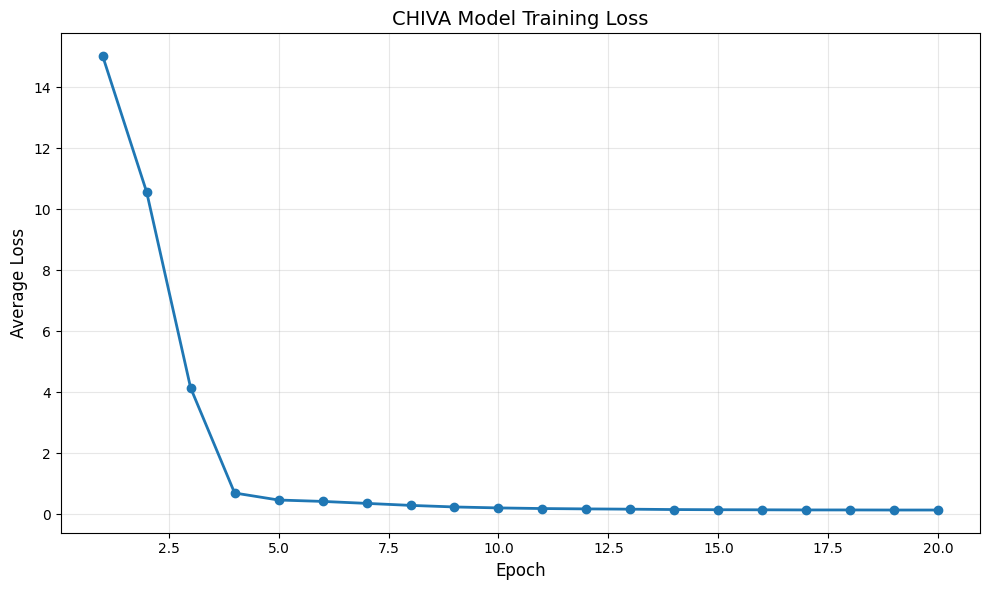

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


✓ Loss plot saved

TESTING MODEL

[Test 1]
Q: Classify: EP N1->N2 at y=0.06 with RP N2->N1 at y=0.25. No N3.
A: - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    - 
    -

[Test 2]
Q: For TYPE 1 shunt, what is the ligation strategy?
A: A- A) B- A+ A- A+ A- 
B- A+ C- A- C- 
C- A- C- A- C- 
D- A- C- A- D- 
E- A- C- A- E-
The classification of the CHIVA (CHIVA 1,2,3) and CHIVA-CHOP (CHOP 1,2,3) is based on the type of venous ins

[Test 3]
Q: Classify: EP N2->N3 at y=0.20 with no EP N1->N2.
A: Type of SFJ is I.
Type of EP N2->N3 is I. 
Type of EP N2->N3 is I. 
Type of EP N2->N3 is I. 
Type of EP N2->N3 is I. 
Type of EP N2->N3 is I. 
Type of EP N2->N3 is I. 
Type of EP N2->N3 is I. 
Type of EP N2->N3

[Test 4]
Q: What is TYPE 2B?
A: I have a
lot of pain and it gets worse with standing. It
gets better when I sit down. I have a

In [7]:
import matplotlib.pyplot as plt

# ============ PLOT ============
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(losses_per_epoch) + 1), losses_per_epoch, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('CHIVA Model Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_loss.png", dpi=100)
plt.show()

print(f"✓ Loss plot saved\n")

# ============ TEST ============
print("="*80)
print("TESTING MODEL")
print("="*80 + "\n")

test_cases = [
    "Classify: EP N1->N2 at y=0.06 with RP N2->N1 at y=0.25. No N3.",
    "For TYPE 1 shunt, what is the ligation strategy?",
    "Classify: EP N2->N3 at y=0.20 with no EP N1->N2.",
    "What is TYPE 2B?",
]

model.eval()
with torch.no_grad():
    for i, prompt in enumerate(test_cases, 1):
        print(f"[Test {i}]")
        print(f"Q: {prompt}")

        inputs = tokenizer.encode(prompt, return_tensors="pt").to(device)

        outputs = model.generate(
            inputs,
            max_new_tokens=100,
            temperature=0.7,
            top_p=0.9,
            do_sample=False,
        )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        print(f"A: {response}\n")

# ============ SUMMARY ============
print("="*80)
print("PHASE 2 COMPLETE!")
print("="*80)
print(f"\nModel saved to: {OUTPUT_DIR}")

**Miscellaneous Code**

In [3]:
!python3 -m pip install jsonlines

In [1]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'

import torch
import json
import jsonlines
from pathlib import Path
from datetime import datetime
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import get_peft_model, LoraConfig, TaskType
import matplotlib.pyplot as plt

print("✓ Imports successful\n")

# ============ CONFIG ============
BASE_DIR = ""  # CHANGE THIS!
BASE_MODEL = "Qwen25-7B"
DATASET_FILE = "training_data_FRESH.jsonl"
OUTPUT_DIR = f"qwen_chiva_tasks_lora"
CACHE_DIR = f".cache"

#Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
#Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)

if not os.path.exists(DATASET_FILE):
    print(f"ERROR: {DATASET_FILE} not found!")
else:
    with jsonlines.open(DATASET_FILE) as f:
        count = sum(1 for _ in f)
    print(f"✓ Dataset: {count} examples")

# ============ DATASET CLASS ============
class SimpleDataset(Dataset):
    def __init__(self, jsonl_file, tokenizer, max_len=512):
        self.data = []
        with jsonlines.open(jsonl_file) as f:
            for line in f:
                self.data.append(line)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = f"Q: {item['input']}\nA: {item['output']}"
        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
        }

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL,
    trust_remote_code=True,
    cache_dir=CACHE_DIR,
)
tokenizer.pad_token = tokenizer.eos_token
print(f"✓ Tokenizer loaded\n")

print("Loading model (2-3 min)...")
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
    cache_dir=CACHE_DIR,
)
total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Model loaded - {total_params / 1e9:.1f}B params\n")

# ============ APPLY LORA ============
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    bias="none",
)
model = get_peft_model(model, lora_config)
model.train()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"✓ LoRA applied")
print(f"  Trainable: {trainable / 1e6:.1f}M ({100 * trainable / total:.2f}%)")
print(f"  Total: {total / 1e9:.1f}B\n")

# ============ DEVICE ============
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB\n")
model = model.to(device)

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


✓ Imports successful

✓ Dataset: 103 examples
Loading tokenizer...
✓ Tokenizer loaded

Loading model (2-3 min)...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:04<00:00, 77.94it/s]


✓ Model loaded - 7.6B params

✓ LoRA applied
  Trainable: 5.0M (0.07%)
  Total: 7.6B

Device: cuda
GPU: NVIDIA GeForce RTX 5090
VRAM: 34.2 GB



In [2]:
# ============ DATASET ============
print("Loading dataset...")
dataset = SimpleDataset(DATASET_FILE, tokenizer, max_len=512)
batch_size = 2
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"✓ Dataset loaded")
print(f"  Examples: {len(dataset)}")
print(f"  Batches: {len(dataloader)}")
print(f"  Batch size: {batch_size}\n")

# ============ OPTIMIZER ============
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.01,
)

num_epochs = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

print(f"✓ Optimizer configured")
print(f"  LR: 1e-4")
print(f"  Epochs: {num_epochs}")
print(f"  Scheduler: Cosine\n")

Loading dataset...
✓ Dataset loaded
  Examples: 103
  Batches: 52
  Batch size: 2

✓ Optimizer configured
  LR: 1e-4
  Epochs: 20
  Scheduler: Cosine



In [3]:
print("="*80)
print("STARTING TRAINING")
print("="*80)
print(f"Start: {datetime.now().isoformat()}\n")

total_loss = 0
global_step = 0
losses_per_epoch = []

for epoch in range(num_epochs):
    epoch_loss = 0
    epoch_steps = 0

    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 40)

    for batch_idx, batch in enumerate(dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids
        )
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        if (batch_idx + 1) % 4 == 0:
            optimizer.step()
            optimizer.zero_grad()

        epoch_loss += loss.item()
        total_loss += loss.item()
        epoch_steps += 1
        global_step += 1

        if (batch_idx + 1) % 5 == 0:
            avg = epoch_loss / epoch_steps
            print(f"  Batch {batch_idx+1}/{len(dataloader)}, Loss: {loss.item():.4f}, Avg: {avg:.4f}")

    scheduler.step()
    avg_epoch = epoch_loss / epoch_steps
    losses_per_epoch.append(avg_epoch)
    print(f"✓ Epoch {epoch+1} - Loss: {avg_epoch:.4f}\n")

print("="*80)
print("TRAINING COMPLETE")
print("="*80)
print(f"End: {datetime.now().isoformat()}")
print(f"Final loss: {total_loss / global_step:.4f}")
print(f"Total steps: {global_step}\n")

# ============ SAVE ============
print("Saving model...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

config = {
    'model': BASE_MODEL,
    'num_examples': len(dataset),
    'epochs': num_epochs,
    'learning_rate': 1e-4,
    'final_loss': total_loss / global_step,
    'total_steps': global_step,
    'timestamp': datetime.now().isoformat(),
}

with open(os.path.join(OUTPUT_DIR, 'training_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f"✓ Model saved to: {OUTPUT_DIR}\n")

STARTING TRAINING
Start: 2026-05-15T11:50:54.894846

Epoch 1/20
----------------------------------------
  Batch 5/52, Loss: 13.7876, Avg: 15.7718
  Batch 10/52, Loss: 14.5581, Avg: 15.7689
  Batch 15/52, Loss: 14.1469, Avg: 15.7630
  Batch 20/52, Loss: 15.9783, Avg: 15.7004
  Batch 25/52, Loss: 15.0298, Avg: 15.6086
  Batch 30/52, Loss: 14.1437, Avg: 15.3141
  Batch 35/52, Loss: 13.0582, Avg: 14.9831
  Batch 40/52, Loss: 12.9154, Avg: 14.8062
  Batch 45/52, Loss: 13.2921, Avg: 14.6752
  Batch 50/52, Loss: 12.2476, Avg: 14.4390
✓ Epoch 1 - Loss: 14.3361

Epoch 2/20
----------------------------------------
  Batch 5/52, Loss: 11.6568, Avg: 12.0199
  Batch 10/52, Loss: 13.1258, Avg: 12.0314
  Batch 15/52, Loss: 9.7696, Avg: 11.8976
  Batch 20/52, Loss: 9.8850, Avg: 11.6501
  Batch 25/52, Loss: 11.3451, Avg: 11.4199
  Batch 30/52, Loss: 11.8937, Avg: 11.4436
  Batch 35/52, Loss: 9.6584, Avg: 11.3223
  Batch 40/52, Loss: 9.6364, Avg: 11.1888
  Batch 45/52, Loss: 8.9302, Avg: 11.0267
  Batc

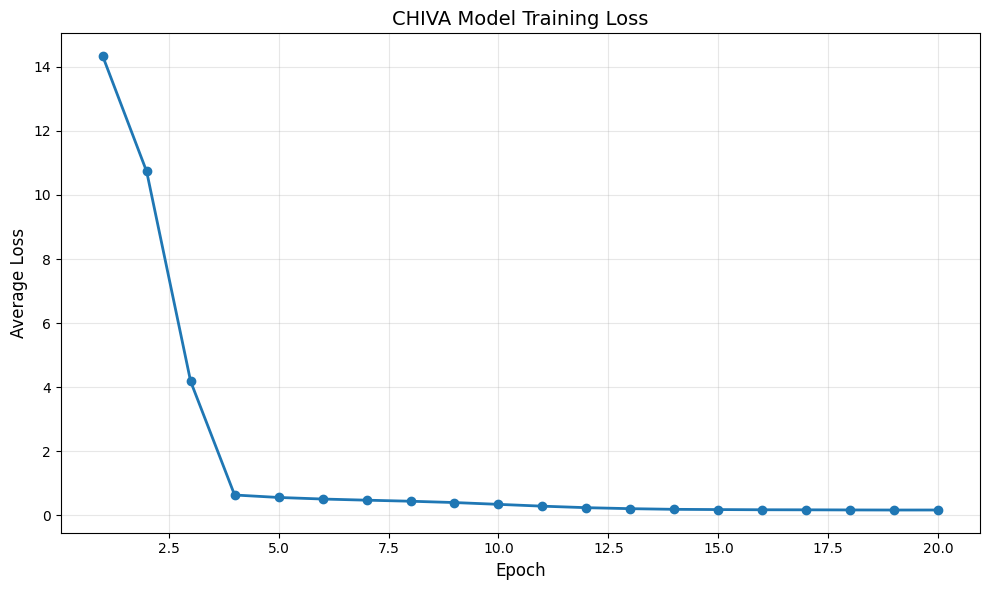

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


✓ Loss plot saved

TESTING MODEL

[Test 1]
Q: Classify: EP N1->N2 at y=0.06 with RP N2->N1 at y=0.25. No N3.
A: - JBI\nClassification: \n- **Type 1 (EP N1->N2, RP N2->N1)**\n- **No N3**\n- **Y-axis:** \n  - **0.06:** EP from N1 to N2\n  - **0.25:** RP from N2 to N1\n- **Conclusion:** This is a simple EP-RP cycle without the presence of N3. - JBI\n

[Test 2]
Q: For TYPE 1 shunt, what is the ligation strategy?
A: Options: - (A) Ligate both branches - (B) Ligate the main trunk - (C) Ligate the draining vein - (D) Ligate the feeding artery
Answer:

For TYPE 1 shunt, the ligation strategy is to:

- (D) Ligate the feeding artery

In TYPE 1 shunts, the abnormal connection involves a small feeding artery and a larger draining vein. The treatment typically focuses on ligating the feeding artery to prevent blood flow through

[Test 3]
Q: Classify: EP N2->N3 at y=0.20 with no EP N1->N2.
A: I'm trying to classify the type of EP based on the following criteria:

- If there is an EP N1->N2, it's a "

In [4]:
# ============ PLOT ============
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(losses_per_epoch) + 1), losses_per_epoch, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('CHIVA Model Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_loss.png", dpi=100)
plt.show()

print(f"✓ Loss plot saved\n")

# ============ TEST ============
print("="*80)
print("TESTING MODEL")
print("="*80 + "\n")

test_cases = [
    "Classify: EP N1->N2 at y=0.06 with RP N2->N1 at y=0.25. No N3.",
    "For TYPE 1 shunt, what is the ligation strategy?",
    "Classify: EP N2->N3 at y=0.20 with no EP N1->N2.",
    "What is TYPE 2B?",
]

model.eval()
with torch.no_grad():
    for i, prompt in enumerate(test_cases, 1):
        print(f"[Test {i}]")
        print(f"Q: {prompt}")

        inputs = tokenizer.encode(prompt, return_tensors="pt").to(device)

        outputs = model.generate(
            inputs,
            max_new_tokens=100,
            temperature=0.7,
            top_p=0.9,
            do_sample=False,
        )

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response[len(prompt):].strip()

        print(f"A: {response}\n")

# ============ SUMMARY ============
print("="*80)
print("PHASE 2 COMPLETE!")
print("="*80)
print(f"\nModel saved to: {OUTPUT_DIR}")
print(f"\nTo use:")
print(f"""
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B",
    torch_dtype=torch.float16,
    device_map="auto"
)
model = PeftModel.from_pretrained(model, "{OUTPUT_DIR}")
tokenizer = AutoTokenizer.from_pretrained("{OUTPUT_DIR}")

model.eval()
with torch.no_grad():
    outputs = model.generate(tokenizer.encode("...", return_tensors="pt").to(model.device))
    print(tokenizer.decode(outputs[0]))
""")

In [5]:
from huggingface_hub import HfApi
import os

api = HfApi()
token = ""
hf_username = "HariKrishna1824"

models = [
    "qwen_medical_pretrained_gpu",
    "qwen_medical_pretrained_resumed"
]

print("="*80)
print("PUSHING TO HF")
print("="*80)

for i, model_name in enumerate(models, 1):
    repo_id = f"{hf_username}/{model_name}"
    
    print(f"\n[{i}/2] {model_name}")
    try:
        api.create_repo(repo_id=repo_id, repo_type="model", token=token, exist_ok=True)
        api.upload_folder(folder_path=model_name, repo_id=repo_id, token=token)
        print("  SUCCESS!")
    except Exception as e:
        print(f"  ERROR: {e}")

print("\n" + "="*80)


PUSHING TO HF

[1/2] qwen_medical_pretrained_gpu


Processing Files (0 / 0): |                                                                |  0.00B /  0.00B            
Processing Files (2 / 3):   0%|▎                                                           |  569kB /  121MB,  356kB/s  
Processing Files (2 / 5):   1%|▌                                                           | 1.16MB /  121MB,  414kB/s  
Processing Files (3 / 6):   2%|█▍                                                          | 2.86MB /  121MB,  953kB/s  
Processing Files (3 / 6):   5%|██▊                                                         | 5.69MB /  121MB, 1.78MB/s  
Processing Files (3 / 6):   6%|███▎                                                        | 6.82MB /  121MB, 1.89MB/s  
Processing Files (3 / 6):   8%|█████                                                       | 10.2MB /  121MB, 2.69MB/s  
Processing Files (3 / 6):  10%|█████▉                                                      | 11.9MB /  121MB, 2.98MB/s  
Processing Files (3 / 6):  11%|█

  SUCCESS!

[2/2] qwen_medical_pretrained_resumed


No files have been modified since last commit. Skipping to prevent empty commit.


  SUCCESS!

